# Data Combination Notebook

**Purpose:** Explore and combine data from multiple sources (CSV, XLSX, JSON)

**Objective:** 
- Identify all files in DATA folder (including subfolders)
- Check column names in each file
- Extract publication date and article content columns
- Combine into single CSV file

---

In [1]:
# Import required libraries
import os
import pandas as pd
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Set the DATA folder path
DATA_FOLDER = Path('DATA')

# Check if DATA folder exists
if DATA_FOLDER.exists():
    print(f"✅ DATA folder found: {DATA_FOLDER.absolute()}")
else:
    print(f"❌ DATA folder not found at: {DATA_FOLDER.absolute()}")
    print("   Please ensure the DATA folder is in the same directory as this notebook")

✅ DATA folder found: /home/hp/INLP/Naretve_Shift/Main_Code/DATA


In [3]:
# Scan DATA folder and identify all files by type
def scan_data_folder(folder_path):
    """
    Recursively scan folder and categorize files by type.
    
    Returns:
        Dictionary with file types as keys and list of file paths as values
    """
    file_inventory = {
        'csv': [],
        'xlsx': [],
        'xls': [],
        'json': [],
        'other': []
    }
    
    # Walk through all directories and subdirectories
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = Path(root) / file
            file_extension = file_path.suffix.lower()
            
            # Categorize by extension
            if file_extension == '.csv':
                file_inventory['csv'].append(file_path)
            elif file_extension in ['.xlsx', '.xls']:
                file_inventory['xlsx'].append(file_path)
            elif file_extension == '.json':
                file_inventory['json'].append(file_path)
            elif file_extension:  # Has an extension but not csv/xlsx/json
                file_inventory['other'].append(file_path)
    
    return file_inventory

# Scan the DATA folder
print("🔍 Scanning DATA folder...")
print("=" * 80)

file_inventory = scan_data_folder(DATA_FOLDER)

# Display summary
print("\n📊 FILE INVENTORY SUMMARY:")
print("=" * 80)
print(f"CSV files:  {len(file_inventory['csv'])}")
print(f"XLSX files: {len(file_inventory['xlsx'])}")
print(f"JSON files: {len(file_inventory['json'])}")
print(f"Other files: {len(file_inventory['other'])}")
print(f"\nTotal data files: {len(file_inventory['csv']) + len(file_inventory['xlsx']) + len(file_inventory['json'])}")

# Display file list by type
for file_type, files in file_inventory.items():
    if files and file_type != 'other':
        print(f"\n\n{'='*80}")
        print(f"📁 {file_type.upper()} FILES ({len(files)}):")
        print('='*80)
        for i, file_path in enumerate(files, 1):
            print(f"   {i}. {file_path}")

🔍 Scanning DATA folder...

📊 FILE INVENTORY SUMMARY:
CSV files:  8
XLSX files: 1
JSON files: 1
Other files: 1

Total data files: 10


📁 CSV FILES (8):
   1. DATA/Covid_News.csv
   2. DATA/CNN_Articels_clean1.csv
   3. DATA/NewsData.io_Sample_data_crypto.csv
   4. DATA/CNN_Articels_clean.csv
   5. DATA/Newsdata_Records_2025_10_27_09_12_28.csv
   6. DATA/kaggle1/data.csv
   7. DATA/kaggle1/raw-data.csv
   8. DATA/kaggle1/rating.csv


📁 XLSX FILES (1):
   1. DATA/NewsSumm Dataset.xlsx


📁 JSON FILES (1):
   1. DATA/us_polices_and_diplomacy.json


---

## 🔍 Step 1: Inspect Column Names in Each File

This section will read each file and display its column names to help identify date and article content columns.

In [4]:
# Function to get columns from different file types
def get_file_columns(file_path):
    """
    Read file and return column names, row count, and sample data.
    
    Returns:
        Dictionary with columns, row_count, and error info
    """
    result = {
        'file_path': str(file_path),
        'file_name': file_path.name,
        'columns': [],
        'row_count': 0,
        'error': None,
        'sample_data': None
    }
    
    try:
        file_extension = file_path.suffix.lower()
        
        # Read CSV files
        if file_extension == '.csv':
            df = pd.read_csv(file_path, nrows=5)  # Read only 5 rows for inspection
            result['columns'] = list(df.columns)
            result['row_count'] = len(pd.read_csv(file_path, usecols=[0]))  # Count rows efficiently
            result['sample_data'] = df.head(2)
        
        # Read Excel files
        elif file_extension in ['.xlsx', '.xls']:
            df = pd.read_excel(file_path, nrows=5)
            result['columns'] = list(df.columns)
            # For Excel, approximate row count to avoid loading entire file
            full_df = pd.read_excel(file_path)
            result['row_count'] = len(full_df)
            result['sample_data'] = df.head(2)
        
        # Read JSON files
        elif file_extension == '.json':
            with open(file_path, 'r', encoding='utf-8') as f:
                # Try to read as JSON array
                try:
                    data = json.load(f)
                    if isinstance(data, list) and len(data) > 0:
                        df = pd.DataFrame(data)
                        result['columns'] = list(df.columns)
                        result['row_count'] = len(df)
                        result['sample_data'] = df.head(2)
                    elif isinstance(data, dict):
                        result['columns'] = list(data.keys())
                        result['row_count'] = 1
                        result['sample_data'] = pd.DataFrame([data]).head(2)
                except:
                    # Try reading as newline-delimited JSON
                    f.seek(0)
                    lines = f.readlines()
                    data = [json.loads(line) for line in lines[:5]]
                    df = pd.DataFrame(data)
                    result['columns'] = list(df.columns)
                    result['row_count'] = len(lines)
                    result['sample_data'] = df.head(2)
    
    except Exception as e:
        result['error'] = str(e)
    
    return result

print("🔍 Inspecting columns in each file...")
print("=" * 80)

# Store all file information
all_files_info = []

# Inspect CSV files
for file_path in file_inventory['csv']:
    info = get_file_columns(file_path)
    all_files_info.append(info)

# Inspect XLSX files
for file_path in file_inventory['xlsx']:
    info = get_file_columns(file_path)
    all_files_info.append(info)

# Inspect JSON files
for file_path in file_inventory['json']:
    info = get_file_columns(file_path)
    all_files_info.append(info)

print(f"✅ Inspected {len(all_files_info)} files")
print("\n" + "=" * 80)

🔍 Inspecting columns in each file...


KeyboardInterrupt: 

In [ ]:
# Display detailed information for each file
print("\n" + "=" * 100)
print("📋 DETAILED FILE INFORMATION")
print("=" * 100)

for i, info in enumerate(all_files_info, 1):
    print(f"\n{'='*100}")
    print(f"FILE {i}: {info['file_name']}")
    print(f"Path: {info['file_path']}")
    print('='*100)
    
    if info['error']:
        print(f"❌ ERROR: {info['error']}")
    else:
        print(f"✅ Rows: {info['row_count']:,}")
        print(f"✅ Columns ({len(info['columns'])}): ")
        
        # Display columns in a formatted way
        for j, col in enumerate(info['columns'], 1):
            print(f"   {j:2d}. {col}")
        
        # Show sample data
        if info['sample_data'] is not None:
            print(f"\n📊 Sample Data (first 2 rows):")
            print("-" * 100)
            display(info['sample_data'])
    
    print()

print("\n" + "=" * 100)
print("✅ Inspection Complete!")
print("=" * 100)
print("\n💡 Next Step: Review the column names above and identify:")
print("   1. Which columns contain DATE/TIME information")
print("   2. Which columns contain ARTICLE CONTENT/TEXT")
print("\n   Then run the next cell to extract and combine the data.")


📋 DETAILED FILE INFORMATION

FILE 1: Covid_News.csv
Path: DATA/Covid_News.csv
✅ Rows: 4,234
✅ Columns (11): 
    1. title
    2. link
    3. keywords
    4. creator
    5. video_url
    6. description
    7. content
    8. pubDate
    9. full_description
   10. image_url
   11. source_id

📊 Sample Data (first 2 rows):
----------------------------------------------------------------------------------------------------


,title,link,keywords,creator,video_url,description,content,pubDate,full_description,image_url,source_id
0,Apple releases iOS 15.1 with SharePlay and mor...,https://www.thehansindia.com/technology/tech-n...,"['Tech,Tech News']",['Kahekashan'],NaN,Apple's latest OS update includes a missing iO...,Apple releases iOS 15.1 with SharePlay and mor...,2021-10-26 06:43:41,NaN,https://assets.thehansindia.com/h-upload/2021/...,thehansindia
1,The Smartest Park on the Block: How One Compan...,https://www.prnewswire.com:443/news-releases/t...,"['Computer & Electronics', 'Networks', 'Teleco...",NaN,NaN,"NEW YORK, Oct. 26, 2021 /PRNewswire/ -- As COV...",NaN,2021-10-26 06:41:00,NaN,NaN,cision




FILE 2: CNN_Articels_clean1.csv
Path: DATA/CNN_Articels_clean1.csv
✅ Rows: 4,076
✅ Columns (11): 
    1. Index
    2. Author
    3. Date published
    4. Category
    5. Section
    6. Url
    7. Headline
    8. Description
    9. Keywords
   10. Second headline
   11. Article text

📊 Sample Data (first 2 rows):
----------------------------------------------------------------------------------------------------


,Index,Author,Date published,Category,Section,Url,Headline,Description,Keywords,Second headline,Article text
0,0,"Jacopo Prisco, CNN",2021-07-15 02:46:59,news,world,https://www.cnn.com/2021/07/14/world/tusimple-...,"There's a shortage of truckers, but TuSimple t...",The e-commerce boom has exacerbated a global t...,"world, There's a shortage of truckers, but TuS...","There's a shortage of truckers, but TuSimple t...","(CNN)Right now, there's a shortage of truck d..."
1,2,"Stephanie Bailey, CNN",2021-05-12 07:52:09,news,world,https://www.cnn.com/2021/05/12/world/ironhand-...,Bioservo's robotic 'Ironhand' could protect fa...,Working in a factory can mean doing the same t...,"world, Bioservo's robotic 'Ironhand' could pro...",A robotic 'Ironhand' could protect factory wor...,(CNN)Working in a factory or warehouse can me...




FILE 3: NewsData.io_Sample_data_crypto.csv
Path: DATA/NewsData.io_Sample_data_crypto.csv
✅ Rows: 100
✅ Columns (18): 
    1. article_id
    2. title
    3. link
    4. keywords
    5. creator
    6. video_url
    7. description
    8. content
    9. pubDate
   10. image_url
   11. source_id
   12. source_priority
   13. source_url
   14. source_icon
   15. language
   16. ai_tag
   17. sentiment
   18. sentiment_stats

📊 Sample Data (first 2 rows):
----------------------------------------------------------------------------------------------------


...



FILE 9: NewsSumm Dataset.xlsx
Path: DATA/NewsSumm Dataset.xlsx
✅ Rows: 348,766
✅ Columns (6): 
    1. newspaper_name
    2. published_date

    3. headline
    4. article_text
    5. human_summary
    6. news_category

📊 Sample Data (first 2 rows):
----------------------------------------------------------------------------------------------------


,newspaper_name,published_date\n,headline,article_text,human_summary,news_category
0,Indian Express,2020-06-01,Virus may be invisible enemy but COVID warrior...,Prime Minister Narendra Modi Monday hailed the...,Prime Minister of India said that the Virus ma...,National News
1,Economic Times,2013-02-11,"Economy can bounce back, says PM Modi","ALLAHABAD: At least 20 persons were killed, an...","In Maha Kumbh, nearly 20 persons were killed. ...",National News




FILE 10: us_polices_and_diplomacy.json
Path: DATA/us_polices_and_diplomacy.json
✅ Rows: 21,750
✅ Columns (26): 
    1. article_id
    2. title
    3. link
    4. keywords
    5. creator
    6. description
    7. content
    8. pubDate
    9. pubDateTZ
   10. image_url
   11. video_url
   12. source_id
   13. source_name
   14. source_priority
   15. source_url
   16. source_icon
   17. language
   18. country
   19. category
   20. sentiment
   21. sentiment_stats
   22. ai_tag
   23. ai_region
   24. ai_org
   25. ai_summary
   26. ai_content

📊 Sample Data (first 2 rows):
----------------------------------------------------------------------------------------------------


,article_id,title,link,keywords,creator,description,content,pubDate,pubDateTZ,image_url,...,language,country,category,sentiment,sentiment_stats,ai_tag,ai_region,ai_org,ai_summary,ai_content
0,0d20b00d56f2d28391640c6c4ed59938,Trump administration says it will stop paying ...,http://www.euronews.com/2025/10/27/trump-admin...,"[food, democrats, united states, us government...",Jerry Fisayo-Bambi,The new notice comes after the Trump administr...,The new notice comes after the Trump administr...,2025-10-27 05:21:35,Europe/London,https://images.euronews.com/articles/stories/0...,...,english,france,"politics, business, top",negative,"{'positive': 1.4, 'neutral': 41.99, 'negative'...","[economy, government]",,[trump],The Trump administration has announced it will...,The Trump administration has made a significan...
1,b324b301f1f6e477d8d57385918e6593,AP News Summary at 1:21 a.m. EDT,https://www.dailysentinel.com/anpa/us/ap-news-...,"[general news, summarybrief]",AP,"For Japan's new leader, the key to connecting ...","For Japan's new leader, the key to connecting ...",2025-10-27 05:21:14,Europe/London,https://bloximages.chicago2.vip.townnews.com/d...,...,english,united states of america,technology,neutral,"{'positive': 0.29, 'neutral': 99.5, 'negative'...",[automotive],"[japan,asia]",[trump],President Donald Trump is set to meet with Jap...,President Donald Trump is scheduled to visit J...




✅ Inspection Complete!

💡 Next Step: Review the column names above and identify:
   1. Which columns contain DATE/TIME information
   2. Which columns contain ARTICLE CONTENT/TEXT

   Then run the next cell to extract and combine the data.


---

## 📝 Summary Table of All Files

Quick reference table showing all files and their columns.

In [ ]:
# Create a summary table
summary_data = []

for info in all_files_info:
    if not info['error']:
        summary_data.append({
            'File Name': info['file_name'],
            'File Type': Path(info['file_path']).suffix.upper(),
            'Rows': info['row_count'],
            'Columns': len(info['columns']),
            'Column Names': ', '.join(info['columns'][:5]) + ('...' if len(info['columns']) > 5 else '')
        })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

print("\n📊 FILES SUMMARY TABLE:")
print("=" * 100)
display(summary_df)

print(f"\n✅ Total files successfully read: {len(summary_df)}")
print(f"✅ Total rows across all files: {summary_df['Rows'].sum():,}")


📊 FILES SUMMARY TABLE:


,File Name,File Type,Rows,Columns,Column Names
0,Covid_News.csv,.CSV,4234,11,"title, link, keywords, creator, video_url..."
1,CNN_Articels_clean1.csv,.CSV,4076,11,"Index, Author, Date published, Category, Secti..."
2,NewsData.io_Sample_data_crypto.csv,.CSV,100,18,"article_id, title, link, keywords, creator..."
3,CNN_Articels_clean.csv,.CSV,37949,11,"Index, Author, Date published, Category, Secti..."
4,Newsdata_Records_2025_10_27_09_12_28.csv,.CSV,23700,26,"article_id, title, link, keywords, creator..."
5,data.csv,.CSV,105375,12,"article_id, source_id, source_name, author, ti..."
6,raw-data.csv,.CSV,933257,11,"article_id, source_id, source_name, author, ti..."
7,rating.csv,.CSV,58356,13,"article_id, source_id, source_name, author, ti..."
8,NewsSumm Dataset.xlsx,.XLSX,348766,6,"newspaper_name, published_date\n, headline, ar..."
9,us_polices_and_diplomacy.json,.JSON,21750,26,"article_id, title, link, keywords, creator..."



✅ Total files successfully read: 10
✅ Total rows across all files: 1,537,563


---

## ⏸️ STOP HERE AND REVIEW

**Before proceeding to the next section:**

1. ✅ Review all the column names displayed above
2. ✅ Identify which columns contain:
   - **Date/Time information** (e.g., `date`, `published_date`, `pubDate`, `timestamp`)
   - **Article content** (e.g., `content`, `text`, `article`, `body`, `description`)
3. ✅ Note any files with errors or unusual formats

Once you've identified the columns, update the mapping in the next cell and proceed with data extraction.

---

---

## 🔧 Step 2: Column Mapping Configuration

**UPDATE THIS CELL AFTER REVIEWING THE OUTPUT ABOVE**

Define the mapping for each file to extract date and article content columns.

In [5]:
# Column mapping configuration
# Based on the file inspection above

COLUMN_MAPPING = {
    # CSV Files
    'Covid_News.csv': {
        'date_column': 'pubDate',
        'content_column': 'content'
    },
    'CNN_Articels_clean1.csv': {
        'date_column': 'Date published',
        'content_column': 'Article text'
    },
    'NewsData.io_Sample_data_crypto.csv': {
        'date_column': 'pubDate',
        'content_column': 'content'
    },
    'CNN_Articels_clean.csv': {
        'date_column': 'Date published',
        'content_column': 'Article text'
    },
    'Newsdata_Records_2025_10_27_09_12_28.csv': {
        'date_column': 'pubDate',
        'content_column': 'content'
    },
    'data.csv': {
        'date_column': 'published_at',
        'content_column': 'full_content'  # Use full_content instead of content for complete articles
    },
    'raw-data.csv': {
        'date_column': 'published_at',
        'content_column': 'content'
    },
    'rating.csv': {
        'date_column': 'published_at',
        'content_column': 'article'  # This file has an 'article' column with full text
    },
    
    # Excel File
    'NewsSumm Dataset.xlsx': {
        'date_column': 'published_date\n',  # Note: has a newline character in the column name
        'content_column': 'article_text'
    },
    
    # JSON File
    'us_polices_and_diplomacy.json': {
        'date_column': 'pubDate',
        'content_column': 'content'
    }
}

print("✅ COLUMN_MAPPING configured!")
print(f"\n📊 Configuration set for {len(COLUMN_MAPPING)} files:")
print("=" * 80)

for i, (filename, mapping) in enumerate(COLUMN_MAPPING.items(), 1):
    print(f"{i:2d}. {filename}")
    print(f"    📅 Date: '{mapping['date_column']}'")
    print(f"    📄 Content: '{mapping['content_column']}'")
    print()

print("✅ Ready to extract and combine data!")
print("\n💡 Next: Run the next cells to extract and combine all data.")

✅ COLUMN_MAPPING configured!

📊 Configuration set for 10 files:
 1. Covid_News.csv
    📅 Date: 'pubDate'
    📄 Content: 'content'

 2. CNN_Articels_clean1.csv
    📅 Date: 'Date published'
    📄 Content: 'Article text'

 3. NewsData.io_Sample_data_crypto.csv
    📅 Date: 'pubDate'
    📄 Content: 'content'

 4. CNN_Articels_clean.csv
    📅 Date: 'Date published'
    📄 Content: 'Article text'

 5. Newsdata_Records_2025_10_27_09_12_28.csv
    📅 Date: 'pubDate'
    📄 Content: 'content'

 6. data.csv
    📅 Date: 'published_at'
    📄 Content: 'full_content'

 7. raw-data.csv
    📅 Date: 'published_at'
    📄 Content: 'content'

 8. rating.csv
    📅 Date: 'published_at'
    📄 Content: 'article'

 9. NewsSumm Dataset.xlsx
    📅 Date: 'published_date
'
    📄 Content: 'article_text'

10. us_polices_and_diplomacy.json
    📅 Date: 'pubDate'
    📄 Content: 'content'

✅ Ready to extract and combine data!

💡 Next: Run the next cells to extract and combine all data.


---

## 🚀 Step 3: Extract and Combine Data

**(Run this section after updating COLUMN_MAPPING)**

This will extract the specified columns from each file and combine them into a single DataFrame.

In [6]:
# Function to extract data from a single file with date format detection and conversion
def extract_data_from_file(file_path, date_col, content_col):
    """
    Extract date and content columns from a file.
    Also detects and converts date formats at the source level.
    
    Returns:
        DataFrame with standardized columns: ['Date', 'Article', 'Source']
    """
    try:
        file_extension = file_path.suffix.lower()
        
        # Read file based on type
        if file_extension == '.csv':
            df = pd.read_csv(file_path)
        elif file_extension in ['.xlsx', '.xls']:
            df = pd.read_excel(file_path)
        elif file_extension == '.json':
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    df = pd.DataFrame(data)
                except:
                    # Try newline-delimited JSON
                    f.seek(0)
                    lines = f.readlines()
                    data = [json.loads(line) for line in lines]
                    df = pd.DataFrame(data)
        
        # Check if required columns exist
        if date_col not in df.columns:
            print(f"   ⚠️  Date column '{date_col}' not found in {file_path.name}")
            return None
        if content_col not in df.columns:
            print(f"   ⚠️  Content column '{content_col}' not found in {file_path.name}")
            return None
        
        # Identify date format for this source
        print(f"   📅 Analyzing date format...")
        date_series = df[date_col]
        
        # Get sample of non-null dates
        sample_dates = date_series[date_series.notna()].head(3)
        if len(sample_dates) > 0:
            print(f"      Sample dates from file:")
            for i, date_val in enumerate(sample_dates, 1):
                print(f"         {i}. {date_val} (type: {type(date_val).__name__})")
        
        # Convert dates to datetime format
        print(f"   🔄 Converting dates to datetime...")
        original_count = len(df)
        
        # Try multiple datetime conversion strategies
        converted_dates = None
        conversion_method = "auto"
        
        # Strategy 1: Auto-detect (handles most formats)
        converted_dates = pd.to_datetime(date_series, errors='coerce')
        initial_success = len(converted_dates) - converted_dates.isnull().sum()
        
        # Strategy 2: If many failures and dates have microseconds, try explicit format
        failed_conversions = converted_dates.isnull().sum() - date_series.isnull().sum()
        if failed_conversions > len(date_series) * 0.3:  # More than 30% failed
            # Check if dates have microsecond format pattern
            sample_str = str(date_series[date_series.notna()].iloc[0]) if len(date_series[date_series.notna()]) > 0 else ""
            
            if '.000000' in sample_str or '.' in sample_str:
                print(f"      ⏳ Detected microseconds format, trying specific parser...")
                # Try format: 'YYYY-MM-DD HH:MM:SS.ffffff'
                try:
                    converted_dates_v2 = pd.to_datetime(date_series, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
                    new_success = len(converted_dates_v2) - converted_dates_v2.isnull().sum()
                    
                    if new_success > initial_success:
                        converted_dates = converted_dates_v2
                        conversion_method = "microseconds"
                        print(f"      ✅ Improved with microseconds parser!")
                except:
                    pass
        
        # Check final conversion success
        failed_conversions = converted_dates.isnull().sum() - date_series.isnull().sum()
        if failed_conversions > 0:
            print(f"      ⚠️  {failed_conversions} dates could not be converted")
        
        success_rate = ((len(converted_dates) - converted_dates.isnull().sum()) / len(converted_dates)) * 100
        print(f"      ✅ Conversion success: {success_rate:.1f}% (method: {conversion_method})")
        
        # Extract required columns with converted dates
        extracted_df = pd.DataFrame({
            'Date': converted_dates,
            'Article': df[content_col],
            'Source': file_path.name  # Track which file the data came from
        })
        
        return extracted_df
    
    except Exception as e:
        print(f"   ❌ Error processing {file_path.name}: {e}")
        return None


# Extract data from all files
if not COLUMN_MAPPING:
    print("❌ COLUMN_MAPPING is empty. Please update it first!")
else:
    print("🔄 Extracting data from files...")
    print("=" * 80)
    
    all_dataframes = []
    
    for file_name, mapping in COLUMN_MAPPING.items():
        # Find the full path for this file
        file_path = None
        for info in all_files_info:
            if Path(info['file_path']).name == file_name:
                file_path = Path(info['file_path'])
                break
        
        if file_path is None:
            print(f"⚠️  File not found: {file_name}")
            continue
        
        print(f"\n📄 Processing: {file_name}")
        print(f"   Date column: {mapping['date_column']}")
        print(f"   Content column: {mapping['content_column']}")
        
        df = extract_data_from_file(
            file_path,
            mapping['date_column'],
            mapping['content_column']
        )
        
        if df is not None:
            all_dataframes.append(df)
            print(f"   ✅ Extracted {len(df):,} rows")
    
    print("\n" + "=" * 80)
    
    if all_dataframes:
        # Combine all dataframes
        combined_df = pd.concat(all_dataframes, ignore_index=True)
        
        print(f"\n✅ Data extraction complete!")
        print(f"   Total rows: {len(combined_df):,}")
        print(f"   Files combined: {len(all_dataframes)}")
        print(f"   Columns: {list(combined_df.columns)}")
    else:
        print("\n❌ No data extracted. Please check COLUMN_MAPPING.")
        combined_df = None

🔄 Extracting data from files...

📄 Processing: Covid_News.csv
   Date column: pubDate
   Content column: content
   📅 Analyzing date format...
      Sample dates from file:
         1. 2021-10-26 06:43:41 (type: str)
         2. 2021-10-26 06:41:00 (type: str)
         3. 2021-10-26 06:35:00 (type: str)
   🔄 Converting dates to datetime...
      ✅ Conversion success: 100.0% (method: auto)
   ✅ Extracted 4,234 rows

📄 Processing: CNN_Articels_clean1.csv
   Date column: Date published
   Content column: Article text
   📅 Analyzing date format...
      Sample dates from file:
         1. 2021-10-26 06:43:41 (type: str)
         2. 2021-10-26 06:41:00 (type: str)
         3. 2021-10-26 06:35:00 (type: str)
   🔄 Converting dates to datetime...
      ✅ Conversion success: 100.0% (method: auto)
   ✅ Extracted 4,234 rows

📄 Processing: CNN_Articels_clean1.csv
   Date column: Date published
   Content column: Article text
   📅 Analyzing date format...
      Sample dates from file:
         1. 2

In [7]:
# Display combined data summary
if combined_df is not None:
    print("\n" + "=" * 80)
    print("📊 COMBINED DATA SUMMARY")
    print("=" * 80)
    
    print(f"\nTotal articles: {len(combined_df):,}")
    print(f"\nData by source:")
    print(combined_df['Source'].value_counts())
    
    print(f"\n\n📋 Sample of combined data:")
    print("=" * 80)
    display(combined_df.head(10))
    
    print(f"\n\n📊 Data Info:")
    print("=" * 80)
    combined_df.info()
    
    # Check for missing values
    print(f"\n\n🔍 Missing Values:")
    print("=" * 80)
    missing = combined_df.isnull().sum()
    print(missing)
    
    if missing.sum() > 0:
        print(f"\n⚠️  Total missing values: {missing.sum():,}")
        print(f"   Missing dates: {missing['Date']:,}")
        print(f"   Missing articles: {missing['Article']:,}")
else:
    print("\n⚠️  No combined data available. Please update COLUMN_MAPPING and re-run.")


📊 COMBINED DATA SUMMARY

Total articles: 1,167,047

Data by source:
Source
raw-data.csv                                933257
data.csv                                    105375
rating.csv                                   58356
CNN_Articels_clean.csv                       37949
Newsdata_Records_2025_10_27_09_12_28.csv     23700
Covid_News.csv                                4234
CNN_Articels_clean1.csv                       4076
NewsData.io_Sample_data_crypto.csv             100
Name: count, dtype: int64


📋 Sample of combined data:


,Date,Article,Source
0,2021-10-26 06:43:41,Apple releases iOS 15.1 with SharePlay and mor...,Covid_News.csv
1,2021-10-26 06:41:00,NaN,Covid_News.csv
2,2021-10-26 06:35:00,NaN,Covid_News.csv
3,2021-10-26 06:34:00,The new SOP stated these patients also must ha...,Covid_News.csv
4,2021-10-26 06:30:29,NaN,Covid_News.csv
5,2021-10-26 06:30:09,NaN,Covid_News.csv
6,2021-10-26 06:25:46,NaN,Covid_News.csv
7,2021-10-26 06:25:23,NaN,Covid_News.csv
8,2021-10-26 06:25:00,Auch bei der dritten Impfung wird priorisiert ...,Covid_News.csv
9,2021-10-26 06:25:00,Auch bei der dritten Impfung wird priorisiert ...,Covid_News.csv




📊 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167047 entries, 0 to 1167046
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype         
---  ------   --------------    -----         
 0   Date     952823 non-null   datetime64[ns]
 1   Article  987844 non-null   object        
 2   Source   1167047 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 26.7+ MB


🔍 Missing Values:
Date       214224
Article    179203
Source          0
dtype: int64

⚠️  Total missing values: 393,427
   Missing dates: 214,224
   Missing articles: 179,203
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167047 entries, 0 to 1167046
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype         
---  ------   --------------    -----         
 0   Date     952823 non-null   datetime64[ns]
 1   Article  987844 non-null   object        
 2   Source   1167047 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 26.

---

## 🧹 Step 4: Data Cleaning

Before saving, we'll clean the data by:
1. Removing duplicate articles
2. Checking if articles are in English
3. Filtering by content length

In [8]:
# Install langdetect for language detection (if not already installed)
try:
    from langdetect import detect, DetectorFactory
    print("✅ langdetect already installed")
except ImportError:
    print("📥 Installing langdetect...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'langdetect'])
    from langdetect import detect, DetectorFactory
    print("✅ langdetect installed successfully")

# Set seed for consistent results
DetectorFactory.seed = 0

print("\n✅ Language detection ready")

✅ langdetect already installed

✅ Language detection ready


In [9]:
# Step 1: Remove duplicate articles, NaN dates, and filter date range
if combined_df is not None:
    print("🔄 Step 1: Removing duplicate articles, NaN dates, and filtering date range...")
    print("=" * 80)
    
    initial_count = len(combined_df)
    print(f"Initial article count: {initial_count:,}")
    
    # Remove exact duplicates based on Article content
    combined_df_clean = combined_df.drop_duplicates(subset=['Article'], keep='first')
    
    duplicates_removed = initial_count - len(combined_df_clean)
    
    print(f"✅ Duplicates removed: {duplicates_removed:,}")
    print(f"✅ Remaining articles: {len(combined_df_clean):,}")
    print(f"   Retention rate: {len(combined_df_clean)/initial_count*100:.1f}%")
    
    # Analyze date types and formats before conversion
    print(f"\n🔍 Analyzing date types and formats before conversion...")
    print("=" * 80)
    
    before_conversion = len(combined_df_clean)
    
    print(f"\n📊 Date Column Analysis:")
    print(f"   Total rows: {before_conversion:,}")
    print(f"   Current date type: {combined_df_clean['Date'].dtype}")
    
    # Count NaN values
    nan_count = combined_df_clean['Date'].isnull().sum()
    print(f"   NaN/empty dates: {nan_count:,} ({nan_count/before_conversion*100:.2f}%)")
    
    # Analyze types of non-NaN dates
    non_nan_dates = combined_df_clean[combined_df_clean['Date'].notna()]['Date']
    
    if len(non_nan_dates) > 0:
        print(f"\n📊 Date Type Distribution (non-NaN dates):")
        
        # Get unique types
        date_types = non_nan_dates.apply(lambda x: type(x).__name__).value_counts()
        for dtype, count in date_types.items():
            pct = (count / len(non_nan_dates)) * 100
            print(f"   {dtype}: {count:,} ({pct:.2f}%)")
        
        print(f"\n📋 Sample dates before conversion (showing different formats):")
        # Show various samples
        sample_dates = non_nan_dates.head(10)
        for i, (idx, date_val) in enumerate(sample_dates.items(), 1):
            print(f"   {i:2d}. {date_val}")
            print(f"       Type: {type(date_val).__name__}")
            print(f"       String representation: '{str(date_val)}'")
            if i >= 5:  # Show first 5 samples
                break
        
        # Check for unique date formats (if string)
        if 'str' in date_types.index or 'object' in str(combined_df_clean['Date'].dtype):
            print(f"\n📋 Unique date format patterns (first 10):")
            unique_formats = non_nan_dates.astype(str).unique()[:10]
            for i, fmt in enumerate(unique_formats, 1):
                print(f"   {i:2d}. {fmt}")
    
    # Convert dates to datetime format
    print(f"\n\n🔄 Converting dates to datetime format...")
    print("=" * 80)
    
    # Convert to datetime (this will convert invalid/NaN to NaT - Not a Time)
    combined_df_clean['Date'] = pd.to_datetime(combined_df_clean['Date'], errors='coerce')
    
    print(f"\n✅ Date conversion complete!")
    print(f"   New date type: {combined_df_clean['Date'].dtype}")
    
    # Now remove all NaN/NaT dates (including original NaN and failed conversions)
    print(f"\n🔄 Removing articles with NaN/empty dates...")
    before_nan_removal = len(combined_df_clean)
    nan_dates = combined_df_clean['Date'].isnull().sum()
    
    print(f"   Articles with NaN/empty dates: {nan_dates:,} ({nan_dates/before_nan_removal*100:.2f}%)")
    print(f"   This includes:")
    print(f"      - Original NaN/empty date fields")
    print(f"      - Dates that could not be parsed/converted")
    
    # Remove all rows with NaN dates
    combined_df_clean = combined_df_clean[combined_df_clean['Date'].notna()].copy()
    
    nan_removed = before_nan_removal - len(combined_df_clean)
    
    print(f"\n✅ NaN/empty dates removed: {nan_removed:,}")
    print(f"✅ Articles remaining: {len(combined_df_clean):,}")
    print(f"   Retention rate after date cleaning: {len(combined_df_clean)/before_nan_removal*100:.1f}%")
    
    # Show final date range (no filtering, just information)
    print(f"\n📊 Final Date Range Information:")
    print(f"   Earliest date: {combined_df_clean['Date'].min().date()}")
    print(f"   Latest date: {combined_df_clean['Date'].max().date()}")
    print(f"   Time span: {(combined_df_clean['Date'].max() - combined_df_clean['Date'].min()).days:,} days")
    
    print(f"\n✅ Overall retention rate: {len(combined_df_clean)/initial_count*100:.1f}%")
    
else:
    print("❌ No combined data available. Please run previous cells first.")

🔄 Step 1: Removing duplicate articles, NaN dates, and filtering date range...
Initial article count: 1,167,047
✅ Duplicates removed: 667,999
✅ Remaining articles: 499,048
   Retention rate: 42.8%

🔍 Analyzing date types and formats before conversion...

📊 Date Column Analysis:
   Total rows: 499,048
   Current date type: datetime64[ns]
   NaN/empty dates: 38,459 (7.71%)

📊 Date Type Distribution (non-NaN dates):
✅ Duplicates removed: 667,999
✅ Remaining articles: 499,048
   Retention rate: 42.8%

🔍 Analyzing date types and formats before conversion...

📊 Date Column Analysis:
   Total rows: 499,048
   Current date type: datetime64[ns]
   NaN/empty dates: 38,459 (7.71%)

📊 Date Type Distribution (non-NaN dates):
   Timestamp: 460,589 (100.00%)

📋 Sample dates before conversion (showing different formats):
    1. 2021-10-26 06:43:41
       Type: Timestamp
       String representation: '2021-10-26 06:43:41'
    2. 2021-10-26 06:41:00
       Type: Timestamp
       String representation: '2

In [10]:
# Step 2: Detect language and keep only English articles (Multi-threaded with 8 threads)
if 'combined_df_clean' in locals() and combined_df_clean is not None:
    print("\n🔄 Step 2: Detecting language and filtering English articles...")
    print("=" * 80)
    
    import threading
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from IPython.display import clear_output
    import time
    
    def detect_language(text):
        """Detect language of text. Returns 'en' for English, or other language code."""
        try:
            if pd.isna(text) or not isinstance(text, str) or len(text.strip()) < 10:
                return 'unknown'
            return detect(str(text))
        except:
            return 'unknown'
    
    def detect_language_batch(batch_data):
        """
        Process a batch of articles and return results with indices.
        batch_data: list of tuples (index, text)
        """
        results = []
        for idx, text in batch_data:
            lang = detect_language(text)
            results.append((idx, lang))
        return results
    
    initial_count = len(combined_df_clean)
    print(f"Articles before language filter: {initial_count:,}")
    print(f"\n⚡ Using multi-threaded processing with 8 threads for faster execution...")
    print(f"Detecting language for each article...")
    print()
    
    # Prepare data for multi-threading
    articles_with_indices = list(enumerate(combined_df_clean['Article']))
    
    # Split data into 8 chunks for parallel processing
    num_threads = 8
    chunk_size = len(articles_with_indices) // num_threads
    chunks = []
    
    for i in range(num_threads):
        start_idx = i * chunk_size
        if i == num_threads - 1:
            # Last chunk gets all remaining items
            end_idx = len(articles_with_indices)
        else:
            end_idx = (i + 1) * chunk_size
        chunks.append(articles_with_indices[start_idx:end_idx])
    
    print(f"📊 Data Distribution:")
    for i, chunk in enumerate(chunks, 1):
        print(f"   Thread {i}: {len(chunk):,} articles")
    print()
    
    # Variables for progress tracking
    processed_count = 0
    english_count = 0
    lock = threading.Lock()
    start_time = time.time()
    
    # Store results and thread progress
    all_results = {}
    thread_progress = {i: 0 for i in range(num_threads)}
    thread_english = {i: 0 for i in range(num_threads)}
    
    # Progress tracking function
    def update_progress():
        progress_pct = (processed_count / initial_count) * 100 if processed_count > 0 else 0
        progress_bar = '█' * int(progress_pct / 2) + '░' * (50 - int(progress_pct / 2))
        elapsed_time = time.time() - start_time
        articles_per_sec = processed_count / elapsed_time if elapsed_time > 0 else 0
        eta = (initial_count - processed_count) / articles_per_sec if articles_per_sec > 0 else 0
        
        clear_output(wait=True)
        print(f"🔄 Step 2: Detecting language and filtering English articles...")
        print("=" * 80)
        print(f"Articles before language filter: {initial_count:,}\n")
        print(f"📊 Thread Progress (each thread processing independently):")
        print("-" * 80)
        for i in range(num_threads):
            chunk_size = len(chunks[i])
            thread_pct = (thread_progress[i] / chunk_size * 100) if chunk_size > 0 else 0
            thread_bar = '█' * int(thread_pct / 10) + '░' * (10 - int(thread_pct / 10))
            print(f"   Thread {i+1}: [{thread_bar}] {thread_pct:5.1f}% | "
                  f"Processed: {thread_progress[i]:>6,}/{chunk_size:>6,} | "
                  f"English: {thread_english[i]:>6,}")
        print("-" * 80)
        print()
        print(f"🔍 Overall Progress: [{progress_bar}] {progress_pct:.1f}%")
        print(f"Total Processed: {processed_count:,}/{initial_count:,} | Total English: {english_count:,}")
        print(f"Speed: {articles_per_sec:.0f} articles/sec | ETA: {eta:.0f}s")
    
    # Process batches with ThreadPoolExecutor
    # Show initial progress display
    update_progress()
    
    # Modified batch function to track individual thread progress
    def detect_language_batch_with_progress(batch_data, thread_id):
        """
        Process a batch of articles and return results with indices.
        Updates thread-specific progress every 100 articles.
        """
        results = []
        local_count = 0
        local_english = 0
        
        for idx, text in batch_data:
            lang = detect_language(text)
            results.append((idx, lang))
            
            local_count += 1
            if lang == 'en':
                local_english += 1
            
            # Update progress every 100 articles within this thread
            if local_count % 100 == 0:
                with lock:
                    thread_progress[thread_id] = local_count
                    thread_english[thread_id] = local_english
                    update_progress()
        
        # Final update for this thread
        with lock:
            thread_progress[thread_id] = local_count
            thread_english[thread_id] = local_english
        
        return results, thread_id
    
    with ThreadPoolExecutor(max_workers=num_threads) as executor:
        # Submit all chunks to thread pool with thread ID
        future_to_chunk = {executor.submit(detect_language_batch_with_progress, chunk, i): i 
                          for i, chunk in enumerate(chunks)}
        
        # Process results as they complete
        for future in as_completed(future_to_chunk):
            chunk_idx = future_to_chunk[future]
            try:
                results, thread_id = future.result()
                
                # Store results
                for idx, lang in results:
                    all_results[idx] = lang
                    
                    with lock:
                        processed_count += 1
                        if lang == 'en':
                            english_count += 1
                
                # Update progress after thread completes
                update_progress()
                
            except Exception as e:
                print(f"\n❌ Error in thread {chunk_idx + 1}: {e}")
    
    # Final progress update
    update_progress()
    
    # Sort results by index and create language list
    languages = [all_results[i] for i in range(len(all_results))]
    
    # Calculate final statistics
    elapsed_total = time.time() - start_time
    final_speed = initial_count / elapsed_total if elapsed_total > 0 else 0
    
    print(f"\n✅ Language detection complete!")
    print(f"   Total time: {elapsed_total:.1f}s")
    print(f"   Average speed: {final_speed:.0f} articles/sec")
    print(f"   Speedup: ~{num_threads:.0f}x faster with multi-threading")
    print()
    
    # Add language column
    combined_df_clean['Language'] = languages
    
    # Show language distribution
    print(f"📊 Language Distribution:")
    lang_dist = combined_df_clean['Language'].value_counts().head(10)
    for lang, count in lang_dist.items():
        pct = (count / initial_count) * 100
        print(f"   {lang}: {count:,} ({pct:.1f}%)")
    
    # Keep only English articles
    combined_df_english = combined_df_clean[combined_df_clean['Language'] == 'en'].copy()
    
    # Drop the Language column as we don't need it anymore
    combined_df_english = combined_df_english.drop('Language', axis=1)
    
    non_english_removed = initial_count - len(combined_df_english)
    
    print(f"\n✅ Non-English articles removed: {non_english_removed:,}")
    print(f"✅ English articles remaining: {len(combined_df_english):,}")
    print(f"   Retention rate: {len(combined_df_english)/initial_count*100:.1f}%")
    
else:
    print("❌ No cleaned data available. Please run previous cells first.")

🔄 Step 2: Detecting language and filtering English articles...
Articles before language filter: 460,589

📊 Thread Progress (each thread processing independently):
--------------------------------------------------------------------------------
   Thread 1: [██████████] 100.0% | Processed: 57,573/57,573 | English: 56,615
   Thread 2: [██████████] 100.0% | Processed: 57,573/57,573 | English: 43,028
   Thread 3: [██████████] 100.0% | Processed: 57,573/57,573 | English: 41,678
   Thread 4: [██████████] 100.0% | Processed: 57,573/57,573 | English: 43,135
   Thread 5: [██████████] 100.0% | Processed: 57,573/57,573 | English: 42,761
   Thread 6: [██████████] 100.0% | Processed: 57,573/57,573 | English: 41,385
   Thread 7: [██████████] 100.0% | Processed: 57,573/57,573 | English: 42,354
   Thread 8: [██████████] 100.0% | Processed: 57,578/57,578 | English: 44,378
--------------------------------------------------------------------------------

🔍 Overall Progress: [█████████████████████████████

In [11]:
# Step 3: Calculate article lengths
if 'combined_df_english' in locals() and combined_df_english is not None:
    print("\n🔄 Step 3: Analyzing article content length...")
    print("=" * 80)
    
    # Calculate length of each article
    combined_df_english['Article_Length'] = combined_df_english['Article'].apply(
        lambda x: len(str(x)) if pd.notna(x) else 0
    )
    
    # Show length statistics
    print(f"\n📊 Article Length Statistics:")
    print(f"   Min length: {combined_df_english['Article_Length'].min()} characters")
    print(f"   Max length: {combined_df_english['Article_Length'].max():,} characters")
    print(f"   Mean length: {combined_df_english['Article_Length'].mean():.0f} characters")
    print(f"   Median length: {combined_df_english['Article_Length'].median():.0f} characters")
    
    # Show distribution
    print(f"\n📊 Length Distribution:")
    bins = [0, 100, 500, 1000, 2000, 5000, float('inf')]
    labels = ['0-100', '101-500', '501-1000', '1001-2000', '2001-5000', '5000+']
    combined_df_english['Length_Category'] = pd.cut(
        combined_df_english['Article_Length'], 
        bins=bins, 
        labels=labels
    )
    print(combined_df_english['Length_Category'].value_counts().sort_index())
    
    # Remove the temporary Length_Category column
    combined_df_english = combined_df_english.drop('Length_Category', axis=1)
    
    print(f"\n✅ Length analysis complete")
    
else:
    print("❌ No English-filtered data available. Please run previous cells first.")


🔄 Step 3: Analyzing article content length...

📊 Article Length Statistics:
   Min length: 10 characters
   Max length: 204,800 characters
   Mean length: 1616 characters
   Median length: 214 characters

📊 Length Distribution:
Length_Category
0-100          2074
101-500      269866
501-1000       1534
1001-2000      9377
2001-5000     39057
5000+         33426
Name: count, dtype: int64

✅ Length analysis complete

📊 Article Length Statistics:
   Min length: 10 characters
   Max length: 204,800 characters
   Mean length: 1616 characters
   Median length: 214 characters

📊 Length Distribution:
Length_Category
0-100          2074
101-500      269866
501-1000       1534
1001-2000      9377
2001-5000     39057
5000+         33426
Name: count, dtype: int64

✅ Length analysis complete


---

## 📊 Cleaning Summary

---

## 🧹 Final Comprehensive Data Cleaning

Apply all quality filters:
- Remove NaN dates
- Remove articles < 500 characters
- Remove articles > 20,000 characters
- Standardize all dates
- Save final clean dataset

In [5]:
# ============================================================================
# LOAD WEBHOUSE FREE-NEWS DATA + COMBINE WITH PROCESSED DATA
# ============================================================================

import os
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

print("=" * 100)
print("📦 LOADING WEBHOUSE FREE-NEWS DATA + COMBINING WITH PROCESSED DATA")
print("=" * 100)

# ============================================================================
# STEP 1: Load Webhouse Free-News Data (JSON files with language metadata)
# ============================================================================

print("\n🔍 STEP 1: Loading Webhouse Free-News Data...")
print("=" * 100)

# Define path to webhouse data
webhouse_folder = Path('DATA/Webhose free-news-datasets master News_Datasets')

# Check if folder exists
if not webhouse_folder.exists():
    print(f"⚠️  Webhouse folder not found at: {webhouse_folder.absolute()}")
    print("   Trying alternative path...")
    webhouse_folder = Path('../DATA/Webhose free-news-datasets master News_Datasets')

if not webhouse_folder.exists():
    print(f"⚠️  Webhouse folder still not found!")
    webhouse_articles = []
else:
    print(f"✅ Webhouse folder found: {webhouse_folder.absolute()}")
    
    # Find all JSON files recursively
    json_files = list(webhouse_folder.rglob('*.json'))
    
    print(f"\n📊 Found {len(json_files):,} JSON files")
    
    if len(json_files) == 0:
        print("⚠️  No JSON files found in webhouse folder")
        webhouse_articles = []
    else:
        print(f"\n🔄 Loading JSON files (English only)...")
        
        webhouse_articles = []
        failed_count = 0
        english_count = 0
        non_english_count = 0
        
        # Progress bar for loading
        for json_file in tqdm(json_files, desc="Processing JSON files"):
            try:
                with open(json_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # Check language first (only load English)
                language = data.get('language', '').lower()
                
                if language == 'english':
                    # Extract required fields
                    article_text = data.get('text', None)
                    published_date = data.get('published', None)
                    
                    # Only add if we have both date and text
                    if published_date and article_text:
                        # Convert date using multi-strategy approach
                        date_obj = None
                        
                        # Strategy 1: Auto-detect (handles most formats including ISO with timezone)
                        try:
                            date_obj = pd.to_datetime(published_date, errors='coerce')
                            
                            # If it has timezone, remove it
                            if date_obj is not pd.NaT and hasattr(date_obj, 'tz') and date_obj.tz is not None:
                                date_obj = date_obj.tz_localize(None)
                        except:
                            pass
                        
                        # Strategy 2: If failed and date has microseconds, try explicit format
                        if date_obj is None or pd.isna(date_obj):
                            if '.000000' in str(published_date) or '.' in str(published_date):
                                try:
                                    date_obj = pd.to_datetime(published_date, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
                                except:
                                    pass
                        
                        article_data = {
                            'Date': date_obj,
                            'Article': article_text,
                            'Source': f"webhouse_{json_file.parent.name}"
                        }
                        webhouse_articles.append(article_data)
                        english_count += 1
                else:
                    non_english_count += 1
                        
            except Exception as e:
                failed_count += 1
        
        print(f"\n✅ Successfully loaded: {english_count:,} English articles")
        print(f"⏭️  Skipped (non-English): {non_english_count:,} articles")
        if failed_count > 0:
            print(f"❌ Failed to load: {failed_count:,} files")

# Create DataFrame from webhouse data
if len(webhouse_articles) > 0:
    df_webhouse = pd.DataFrame(webhouse_articles)
    
    # Check date conversion success
    valid_dates = df_webhouse['Date'].notna().sum()
    total_dates = len(df_webhouse)
    success_rate = (valid_dates / total_dates * 100) if total_dates > 0 else 0
    
    print(f"\n📊 Webhouse DataFrame shape: {df_webhouse.shape}")
    print(f"📅 Date conversion success: {success_rate:.1f}% ({valid_dates:,}/{total_dates:,} valid dates)")
else:
    df_webhouse = pd.DataFrame(columns=['Date', 'Article', 'Source'])
    print(f"\n⚠️  No webhouse data loaded - created empty DataFrame")

# ============================================================================
# STEP 2: Load All CSV Files from Processed_Data/Stage_0 Folder
# ============================================================================

print("\n" + "=" * 100)
print("🔍 STEP 2: Loading Processed CSV Files from Stage_0...")
print("=" * 100)

processed_folder = Path('/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Stage_0')

# Find all CSV files recursively in Processed_Data/Stage_0
csv_files = []
if processed_folder.exists():
    csv_files = list(processed_folder.rglob('*.csv'))
    print(f"\n📊 Found {len(csv_files):,} CSV files in Processed_Data/Stage_0")
else:
    print(f"⚠️  Processed_Data/Stage_0 folder not found at: {processed_folder.absolute()}")

processed_dataframes = []

if len(csv_files) > 0:
    print(f"\n🔄 Loading CSV files...")
    
    for csv_file in tqdm(csv_files, desc="Loading CSV files"):
        try:
            df_temp = pd.read_csv(csv_file, low_memory=False)
            
            # Standardize column names (case-insensitive mapping)
            column_mapping = {}
            
            for col in df_temp.columns:
                col_lower = col.lower().strip()
                
                # Map date columns
                if any(x in col_lower for x in ['date', 'published', 'time']):
                    column_mapping[col] = 'Date'
                # Map article/content columns
                elif any(x in col_lower for x in ['article', 'text', 'content', 'body']):
                    column_mapping[col] = 'Article'
                # Map source columns
                elif any(x in col_lower for x in ['source', 'origin', 'publisher']):
                    column_mapping[col] = 'Source'
            
            # Rename columns
            if column_mapping:
                df_temp = df_temp.rename(columns=column_mapping)
            
            # Keep only Date, Article, Source columns if they exist
            required_cols = ['Date', 'Article', 'Source']
            available_cols = [col for col in required_cols if col in df_temp.columns]
            
            if 'Date' in available_cols and 'Article' in available_cols:
                df_temp = df_temp[available_cols].copy()
                
                # Convert Date to datetime object using multi-strategy conversion
                date_series = df_temp['Date']
                original_count = len(df_temp)
                
                # Strategy 1: Auto-detect (handles most formats)
                converted_dates = pd.to_datetime(date_series, errors='coerce')
                initial_success = len(converted_dates) - converted_dates.isnull().sum()
                conversion_method = "auto"
                
                # Strategy 2: If many failures and dates have microseconds, try explicit format
                failed_conversions = converted_dates.isnull().sum() - date_series.isnull().sum()
                if failed_conversions > len(date_series) * 0.3:  # More than 30% failed
                    # Check if dates have microsecond format pattern
                    sample_str = str(date_series[date_series.notna()].iloc[0]) if len(date_series[date_series.notna()]) > 0 else ""
                    
                    if '.000000' in sample_str or '.' in sample_str:
                        # Try format: 'YYYY-MM-DD HH:MM:SS.ffffff'
                        try:
                            converted_dates_v2 = pd.to_datetime(date_series, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
                            new_success = len(converted_dates_v2) - converted_dates_v2.isnull().sum()
                            
                            if new_success > initial_success:
                                converted_dates = converted_dates_v2
                                conversion_method = "microseconds"
                        except:
                            pass
                
                df_temp['Date'] = converted_dates
                
                # Add source if missing
                if 'Source' not in df_temp.columns:
                    df_temp['Source'] = csv_file.stem
                
                # Calculate success rate
                success_count = len(df_temp) - df_temp['Date'].isnull().sum()
                success_rate = (success_count / len(df_temp)) * 100 if len(df_temp) > 0 else 0
                
                processed_dataframes.append(df_temp)
                print(f"  ✅ Loaded: {csv_file.name} ({len(df_temp):,} rows, date conversion: {success_rate:.1f}%, method: {conversion_method})")
            else:
                print(f"  ⏭️  Skipped: {csv_file.name} (missing required columns)")
                
        except Exception as e:
            print(f"  ❌ Failed: {csv_file.name} - {str(e)}")

print(f"\n✅ Successfully loaded {len(processed_dataframes)} CSV files")

# ============================================================================
# STEP 3: Combine All DataFrames
# ============================================================================

print("\n" + "=" * 100)
print("🔗 STEP 3: Combining All Data...")
print("=" * 100)

# Combine all dataframes
all_dfs = []

# Add webhouse data
if len(df_webhouse) > 0:
    all_dfs.append(df_webhouse)
    print(f"  ✅ Added webhouse data: {len(df_webhouse):,} rows")

# Add processed CSV data
if len(processed_dataframes) > 0:
    all_dfs.extend(processed_dataframes)
    total_processed = sum(len(df) for df in processed_dataframes)
    print(f"  ✅ Added processed CSV data: {total_processed:,} rows")

if len(all_dfs) == 0:
    print("⚠️  No data to combine!")
    combined_df_english = pd.DataFrame(columns=['Date', 'Article', 'Source'])
else:
    # Combine all dataframes
    combined_df_english = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n📊 Combined DataFrame shape (before cleaning): {combined_df_english.shape}")
    
    # ============================================================================
    # STEP 4: Clean Combined Data
    # ============================================================================
    
    print("\n" + "=" * 100)
    print("🧹 STEP 4: Cleaning Combined Data...")
    print("=" * 100)
    
    initial_count = len(combined_df_english)
    
    # Check date formats (webhouse dates already converted, CSV dates should be in correct format)
    print("\n📅 Checking date formats...")
    if len(combined_df_english) > 0:
        sample_date = combined_df_english['Date'].iloc[0]
        print(f"  ✅ Sample date: {sample_date}")
        print(f"  ✅ Date type: {type(sample_date)}")
    
    # Remove rows with NaN dates
    before_date_drop = len(combined_df_english)
    combined_df_english = combined_df_english.dropna(subset=['Date']).copy()
    date_dropped = before_date_drop - len(combined_df_english)
    print(f"  ❌ Removed {date_dropped:,} rows with invalid dates")
    
    # Show sample of date format after filtering
    if len(combined_df_english) > 0:
        print(f"  ✅ Date format example: {combined_df_english['Date'].iloc[0]}")
    
    # Remove rows with NaN articles
    before_article_drop = len(combined_df_english)
    combined_df_english = combined_df_english.dropna(subset=['Article']).copy()
    article_dropped = before_article_drop - len(combined_df_english)
    print(f"  ❌ Removed {article_dropped:,} rows with missing articles")
    
    # Remove duplicates based on Article text
    before_dup_drop = len(combined_df_english)
    combined_df_english = combined_df_english.drop_duplicates(subset=['Article'], keep='first').copy()
    dup_dropped = before_dup_drop - len(combined_df_english)
    print(f"  ❌ Removed {dup_dropped:,} duplicate articles")
    
    # Sort by date
    combined_df_english = combined_df_english.sort_values('Date').reset_index(drop=True)
    
    # Calculate article lengths
    combined_df_english['Article_Length'] = combined_df_english['Article'].str.len()
    
    print(f"\n✅ Final combined DataFrame shape: {combined_df_english.shape}")
    print(f"📊 Total articles retained: {len(combined_df_english):,}")
    print(f"📅 Date range: {combined_df_english['Date'].min()} to {combined_df_english['Date'].max()}")
    
    # ============================================================================
    # STEP 5: Save Combined Data
    # ============================================================================
    
    print("\n" + "=" * 100)
    print("💾 STEP 5: Saving Combined Data...")
    print("=" * 100)
    
    # Create output folder - save to parent Processed_Data folder
    output_folder = Path('/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data')
    output_folder.mkdir(exist_ok=True, parents=True)
    
    output_file = output_folder / 'ALL_Combined_Data.csv'
    
    # Save to CSV
    combined_df_english.to_csv(output_file, index=False)
    print(f"\n✅ Saved combined data to: {output_file.absolute()}")
    print(f"📊 File size: {output_file.stat().st_size / (1024*1024):.2f} MB")
    
    # Display summary statistics
    print("\n" + "=" * 100)
    print("📈 SUMMARY STATISTICS")
    print("=" * 100)
    
    print(f"\n📊 Total Articles: {len(combined_df_english):,}")
    print(f"\n📅 Date Range:")
    print(f"  • Earliest: {combined_df_english['Date'].min()}")
    print(f"  • Latest: {combined_df_english['Date'].max()}")
    print(f"  • Time span: {(combined_df_english['Date'].max() - combined_df_english['Date'].min()).days:,} days")
    
    print(f"\n📏 Article Length Statistics:")
    print(f"  • Mean: {combined_df_english['Article_Length'].mean():.0f} characters")
    print(f"  • Median: {combined_df_english['Article_Length'].median():.0f} characters")
    print(f"  • Min: {combined_df_english['Article_Length'].min():,} characters")
    print(f"  • Max: {combined_df_english['Article_Length'].max():,} characters")
    
    print(f"\n📰 Top 10 Sources:")
    source_counts = combined_df_english['Source'].value_counts().head(10)
    for source, count in source_counts.items():
        print(f"  • {source}: {count:,} articles ({count/len(combined_df_english)*100:.1f}%)")
    
    print("\n" + "=" * 100)
    print("✅ DATA LOADING AND COMBINING COMPLETE!")
    print("=" * 100)
    print(f"\n💡 Variable 'combined_df_english' is ready for use in subsequent cells")
    print(f"📊 Shape: {combined_df_english.shape}")
    print(f"📋 Columns: {list(combined_df_english.columns)}")
    print(f"📅 Date stored as: datetime64[ns] objects (not strings)")


📦 LOADING WEBHOUSE FREE-NEWS DATA + COMBINING WITH PROCESSED DATA

🔍 STEP 1: Loading Webhouse Free-News Data...
⚠️  Webhouse folder not found at: /home/hp/SEM2/INLP/Naretve_Shift/Pre_Processin/DATA/Webhose free-news-datasets master News_Datasets
   Trying alternative path...
✅ Webhouse folder found: /home/hp/SEM2/INLP/Naretve_Shift/Pre_Processin/../DATA/Webhose free-news-datasets master News_Datasets

📊 Found 61,000 JSON files

🔄 Loading JSON files (English only)...

📊 Found 61,000 JSON files

🔄 Loading JSON files (English only)...


Processing JSON files: 100%|██████████| 61000/61000 [00:33<00:00, 1832.13it/s]




✅ Successfully loaded: 35,449 English articles
⏭️  Skipped (non-English): 25,551 articles

📊 Webhouse DataFrame shape: (35449, 3)
📅 Date conversion success: 100.0% (35,449/35,449 valid dates)

🔍 STEP 2: Loading Processed CSV Files from Stage_0...

📊 Found 347 CSV files in Processed_Data/Stage_0

🔄 Loading CSV files...


Loading CSV files:   0%|          | 0/347 [00:00<?, ?it/s]

  ✅ Loaded: Data_182.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_68.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_171.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_324.csv (1,000 rows, date conversion: 100.0%, method: auto)


...

Loading CSV files:  97%|█████████▋| 338/347 [00:09<00:00, 32.99it/s]

  ✅ Loaded: Data_12.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_239.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_291.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_238.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_25.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_27.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_269.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_28.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_27.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_269.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_28.csv (1,000 rows, date conversion: 100.0%, method: auto)


Loading CSV files: 100%|██████████| 347/347 [00:10<00:00, 33.72it/s]

  ✅ Loaded: Data_37.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_259.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_163.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_86.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_120.csv (1,000 rows, date conversion: 100.0%, method: auto)
  ✅ Loaded: Data_243.csv (1,000 rows, date conversion: 100.0%, method: auto)

✅ Successfully loaded 347 CSV files

🔗 STEP 3: Combining All Data...
  ✅ Added webhouse data: 35,449 rows
  ✅ Added processed CSV data: 346,728 rows

📊 Combined DataFrame shape (before cleaning): (382177, 3)

🧹 STEP 4: Cleaning Combined Data...

📅 Checking date formats...
  ✅ Sample date: 2024-04-04 03:00:00
  ✅ Date type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


  ❌ Removed 0 rows with invalid dates
  ✅ Date format example: 2024-04-04 03:00:00
  ❌ Removed 0 rows with missing articles
  ❌ Removed 2,879 duplicate articles
  ❌ Removed 2,879 duplicate articles

✅ Final combined DataFrame shape: (379298, 4)
📊 Total articles retained: 379,298
📅 Date range: 2011-08-24 17:54:07 to 2026-01-15 08:18:59.245000

💾 STEP 5: Saving Combined Data...

✅ Final combined DataFrame shape: (379298, 4)
📊 Total articles retained: 379,298
📅 Date range: 2011-08-24 17:54:07 to 2026-01-15 08:18:59.245000

💾 STEP 5: Saving Combined Data...

✅ Saved combined data to: /home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/ALL_Combined_Data.csv
📊 File size: 595.39 MB

📈 SUMMARY STATISTICS

📊 Total Articles: 379,298

📅 Date Range:
  • Earliest: 2011-08-24 17:54:07
  • Latest: 2026-01-15 08:18:59.245000
  • Time span: 5,257 days

📏 Article Length Statistics:
  • Mean: 1587 characters
  • Median: 214 characters
  • Min: 4 characters
  • Max: 100,000 characters

📰 Top 10 Sources:
  • r

In [6]:
# COMPREHENSIVE DATA CLEANING STAGE
# This stage applies ALL quality filters to prepare data for learning

if 'combined_df_english' in locals() and combined_df_english is not None:
    
    print("=" * 100)
    print("🧹 COMPREHENSIVE DATA CLEANING FOR LEARNING STAGE")
    print("=" * 100)
    
    # Start with English-filtered data
    df_for_learning = combined_df_english.copy()
    
    print(f"\n📊 Initial Dataset Statistics:")
    print(f"   Total articles: {len(df_for_learning):,}")
    print(f"   Columns: {list(df_for_learning.columns)}")
    
    # ============================================================================
    # STEP 1: Remove NaN Dates ONLY
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"🔧 STEP 1: Removing Articles with NaN Dates")
    print("=" * 100)
    
    initial_count = len(df_for_learning)
    nan_dates_before = df_for_learning['Date'].isnull().sum()
    
    print(f"\n📊 Before NaN Date Removal:")
    print(f"   Total articles: {initial_count:,}")
    print(f"   Articles with NaN dates: {nan_dates_before:,} ({nan_dates_before/initial_count*100:.2f}%)")
    print(f"   Articles with valid dates: {initial_count - nan_dates_before:,}")
    
    # Remove NaN dates
    df_for_learning = df_for_learning[df_for_learning['Date'].notna()].copy()
    
    articles_removed_nan = initial_count - len(df_for_learning)
    
    print(f"\n✅ After NaN Date Removal:")
    print(f"   Articles removed: {articles_removed_nan:,}")
    print(f"   Articles remaining: {len(df_for_learning):,}")
    print(f"   Retention rate: {len(df_for_learning)/initial_count*100:.2f}%")
    
    # ============================================================================
    # STEP 2: Save All Articles (after NaN removal, before length filtering)
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"💾 STEP 2: Saving All Articles (Before Length Filtering)")
    print("=" * 100)
    
    # Prepare data for saving (without Article_Length column if it exists)
    df_all_articles = df_for_learning.copy()
    if 'Article_Length' in df_all_articles.columns:
        df_all_articles = df_all_articles.drop('Article_Length', axis=1)
    
    # Save to CSV
    all_articles_file = 'all_articles_english_with_dates.csv'
    df_all_articles.to_csv(all_articles_file, index=False)
    
    print(f"\n✅ All Articles Saved!")
    print(f"   File: {all_articles_file}")
    print(f"   Location: {Path(all_articles_file).absolute()}")
    print(f"   Total articles: {len(df_all_articles):,}")
    print(f"   Columns: {list(df_all_articles.columns)}")
    
    if os.path.exists(all_articles_file):
        file_size_mb = os.path.getsize(all_articles_file) / (1024*1024)
        print(f"   File size: {file_size_mb:.2f} MB")
    
    print(f"\n📊 Date Range in Saved File:")
    print(f"   Earliest: {df_all_articles['Date'].min().date()}")
    print(f"   Latest: {df_all_articles['Date'].max().date()}")
    print(f"   Time span: {(df_all_articles['Date'].max() - df_all_articles['Date'].min()).days:,} days")
    
    # ============================================================================
    # STEP 3: Calculate Article Lengths
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"📏 STEP 3: Calculating Article Lengths")
    print("=" * 100)
    
    if 'Article_Length' not in df_for_learning.columns:
        df_for_learning['Article_Length'] = df_for_learning['Article'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )
        print(f"\n✅ Article length calculated for all articles")
    else:
        print(f"\n✅ Article length already present")
    
    print(f"\n📊 Length Statistics (Before Filtering):")
    print(f"   Min length: {df_for_learning['Article_Length'].min():,} characters")
    print(f"   Max length: {df_for_learning['Article_Length'].max():,} characters")
    print(f"   Mean length: {df_for_learning['Article_Length'].mean():,.0f} characters")
    print(f"   Median length: {df_for_learning['Article_Length'].median():,.0f} characters")
    
    # Show detailed distribution
    print(f"\n📊 Detailed Length Distribution:")
    bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 30000, 50000, float('inf')]
    labels = ['0-50', '51-100', '101-200', '201-500', '501-1000', '1001-2000', '2001-5000', 
              '5001-10000', '10001-20000', '20001-30000', '30001-50000', '50000+']
    df_for_learning['Length_Category'] = pd.cut(
        df_for_learning['Article_Length'], 
        bins=bins, 
        labels=labels
    )
    
    length_dist = df_for_learning['Length_Category'].value_counts().sort_index()
    print(f"\n{'Length Range':<20} {'Count':>15} {'Percentage':>12}")
    print("-" * 100)
    for category, count in length_dist.items():
        pct = (count / len(df_for_learning) * 100)
        print(f"{category:<20} {count:>15,} {pct:>11.2f}%")
    
    # Drop temporary column
    df_for_learning = df_for_learning.drop('Length_Category', axis=1)
    
    # ============================================================================
    # STEP 4: Apply Length Filters (200 - 30,000 characters)
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"🔧 STEP 4: Applying Length Filters (200 - 30,000 characters)")
    print("=" * 100)
    
    before_length_filter = len(df_for_learning)
    
    # Count articles outside the range
    below_200 = (df_for_learning['Article_Length'] < 200).sum()
    above_30000 = (df_for_learning['Article_Length'] > 30000).sum()
    in_range = ((df_for_learning['Article_Length'] >= 200) & 
                (df_for_learning['Article_Length'] <= 30000)).sum()
    
    print(f"\n📊 Length Analysis:")
    print(f"   Total articles: {before_length_filter:,}")
    print(f"   Articles < 200 chars: {below_200:,} ({below_200/before_length_filter*100:.2f}%)")
    print(f"   Articles > 30,000 chars: {above_30000:,} ({above_30000/before_length_filter*100:.2f}%)")
    print(f"   Articles in range (200-30,000): {in_range:,} ({in_range/before_length_filter*100:.2f}%)")
    print(f"   Total to be removed: {below_200 + above_30000:,} ({(below_200 + above_30000)/before_length_filter*100:.2f}%)")
    
    # Show samples of articles that will be removed
    if below_200 > 0:
        print(f"\n📋 Sample of SHORT articles (< 200 chars) that will be removed:")
        short_articles = df_for_learning[df_for_learning['Article_Length'] < 200].head(5)
        for i, (idx, row) in enumerate(short_articles.iterrows(), 1):
            preview = str(row['Article'])[:100] + ('...' if len(str(row['Article'])) > 100 else '')
            print(f"   {i}. Length: {row['Article_Length']} chars | Source: {row['Source']}")
            print(f"      Preview: \"{preview}\"")
    
    if above_30000 > 0:
        print(f"\n📋 Sample of LONG articles (> 30,000 chars) that will be removed:")
        long_articles = df_for_learning[df_for_learning['Article_Length'] > 30000].head(5)
        for i, (idx, row) in enumerate(long_articles.iterrows(), 1):
            preview = str(row['Article'])[:100] + '...'
            print(f"   {i}. Length: {row['Article_Length']:,} chars | Source: {row['Source']} | Date: {row['Date'].date()}")
            print(f"      Preview: \"{preview}\"")
    
    # Apply length filters
    df_for_learning = df_for_learning[
        (df_for_learning['Article_Length'] >= 500) & 
        (df_for_learning['Article_Length'] <= 50000)
    ].copy()
    
    removed_by_length = before_length_filter - len(df_for_learning)
    
    print(f"\n✅ Length Filters Applied!")
    print(f"   Articles removed: {removed_by_length:,}")
    print(f"   Articles remaining: {len(df_for_learning):,}")
    print(f"   Retention rate: {len(df_for_learning)/before_length_filter*100:.2f}%")
    
    # ============================================================================
    # STEP 5: Final Statistics and Decision Point
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"📊 STEP 5: Final Statistics After Length Filtering")
    print("=" * 100)
    
    
    print(f"\n📊 Final Length Statistics (200-30,000 chars):")
    print(f"   Total articles: {len(df_for_learning):,}")
    print(f"   Min length: {df_for_learning['Article_Length'].min():,} characters")
    print(f"   Max length: {df_for_learning['Article_Length'].max():,} characters")
    print(f"   Mean length: {df_for_learning['Article_Length'].mean():,.0f} characters")
    print(f"   Median length: {df_for_learning['Article_Length'].median():,.0f} characters")
    print(f"   Std deviation: {df_for_learning['Article_Length'].std():,.0f} characters")
    
    # Final distribution within the range
    print(f"\n📊 Final Length Distribution (200-30,000 chars):")
    bins_final = [200, 500, 1000, 2000, 5000, 10000, 20000, 30000]
    labels_final = ['200-500', '501-1000', '1001-2000', '2001-5000', '5001-10000', '10001-20000', '20001-30000']
    df_for_learning['Length_Category_Final'] = pd.cut(
        df_for_learning['Article_Length'], 
        bins=bins_final, 
        labels=labels_final
    )
    
    length_dist_final = df_for_learning['Length_Category_Final'].value_counts().sort_index()
    print(f"\n{'Length Range':<20} {'Count':>15} {'Percentage':>12}")
    print("-" * 100)
    for category, count in length_dist_final.items():
        pct = (count / len(df_for_learning) * 100)
        print(f"{category:<20} {count:>15,} {pct:>11.2f}%")
    
    # Drop temporary column
    df_for_learning = df_for_learning.drop('Length_Category_Final', axis=1)
    
    # ============================================================================
    # DECISION POINT - SHOW SUMMARY BEFORE FINAL SAVE
    # ============================================================================
    print(f"\n\n{'=' * 100}")
    print(f"⏸️  DECISION POINT - Review Statistics")
    print("=" * 100)
    
    print(f"\n📊 Summary of Filtering:")
    print(f"   Original (English + Valid dates): {before_length_filter:,} articles")
    print(f"   After length filter (200-30,000): {len(df_for_learning):,} articles")
    print(f"   Removed (< 200 chars): {below_200:,} ({below_200/before_length_filter*100:.2f}%)")
    print(f"   Removed (> 30,000 chars): {above_30000:,} ({above_30000/before_length_filter*100:.2f}%)")
    print(f"   Total removed: {removed_by_length:,} ({removed_by_length/before_length_filter*100:.2f}%)")
    print(f"   Retention rate: {len(df_for_learning)/before_length_filter*100:.2f}%")
    
    print(f"\n📁 Files Created:")
    print(f"   1. all_articles_english_with_dates.csv - {before_length_filter:,} articles (all English with dates)")
    print(f"   2. Ready to save: final_clean_data_for_learning.csv - {len(df_for_learning):,} articles (200-30,000 chars)")
    
    print(f"\n💡 You can now:")
    print(f"   - Review the statistics above")
    print(f"   - Adjust the length thresholds if needed (currently 200-30,000)")
    print(f"   - Save the filtered data by running the next cell or continuing below")
    
    # Store the filtered dataframe
    df_final_for_learning = df_for_learning.copy()
    
    print(f"\n✅ Variable 'df_final_for_learning' is ready with {len(df_final_for_learning):,} articles")
    print(f"=" * 100)
    
else:
    print("❌ No data available. Please run previous cells first.")

🧹 COMPREHENSIVE DATA CLEANING FOR LEARNING STAGE

📊 Initial Dataset Statistics:
   Total articles: 379,298
   Columns: ['Date', 'Article', 'Source', 'Article_Length']


🔧 STEP 1: Removing Articles with NaN Dates

📊 Before NaN Date Removal:
   Total articles: 379,298
   Articles with NaN dates: 0 (0.00%)
   Articles with valid dates: 379,298

✅ After NaN Date Removal:
   Articles removed: 0
   Articles remaining: 379,298
   Retention rate: 100.00%


💾 STEP 2: Saving All Articles (Before Length Filtering)



✅ All Articles Saved!
   File: all_articles_english_with_dates.csv
   Location: /home/hp/SEM2/INLP/Naretve_Shift/Pre_Processin/all_articles_english_with_dates.csv
   Total articles: 379,298
   Columns: ['Date', 'Article', 'Source']
   File size: 593.90 MB

📊 Date Range in Saved File:
   Earliest: 2011-08-24
   Latest: 2026-01-15
   Time span: 5,257 days


📏 STEP 3: Calculating Article Lengths

✅ Article length already present

📊 Length Statistics (Before Filtering):
   Min length: 4 characters
   Max length: 100,000 characters
   Mean length: 1,587 characters
   Median length: 214 characters

📊 Detailed Length Distribution:

Length Range                   Count   Percentage
----------------------------------------------------------------------------------------------------
0-50                              41        0.01%
51-100                           187        0.05%
101-200                          466        0.12%
201-500                      266,191       70.18%
501-1000       

In [ ]:
# Split dataframe into chunks of 1000 and save to separate CSV files
if 'df_final_for_learning' in locals() and df_final_for_learning is not None:
    
    print("=" * 100)
    print("📦 SPLITTING DATA INTO CHUNKS AND SAVING TO SEPARATE FILES")
    print("=" * 100)
    
    # Create Data_Files folder if it doesn't exist
    data_files_folder = Path('/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Stage_0')
    data_files_folder.mkdir(exist_ok=True)
    
    print(f"\n📁 Output folder: {data_files_folder.absolute()}")
    
    # Remove Article_Length column if it exists (we don't need it in the final files)
    df_to_split = df_final_for_learning.copy()
    if 'Article_Length' in df_to_split.columns:
        df_to_split = df_to_split.drop('Article_Length', axis=1)
    
    # Configuration
    chunk_size = 1000
    total_articles = len(df_to_split)
    num_chunks = (total_articles + chunk_size - 1) // chunk_size  # Ceiling division
    
    print(f"\n📊 Split Configuration:")
    print(f"   Total articles: {total_articles:,}")
    print(f"   Chunk size: {chunk_size:,} articles per file")
    print(f"   Number of files to create: {num_chunks}")
    
    print(f"\n🔄 Creating CSV files...")
    print("-" * 100)
    
    # Split and save
    saved_files = []
    
    for i in range(num_chunks):
        # Calculate start and end indices
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, total_articles)
        
        # Extract chunk
        chunk_df = df_to_split.iloc[start_idx:end_idx].copy()
        
        # Create filename (Data_1.csv, Data_2.csv, etc.)
        file_name = f"Data_{i + 1}.csv"
        file_path = data_files_folder / file_name
        
        # Save to CSV
        chunk_df.to_csv(file_path, index=False)
        
        # Get file size
        file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
        
        # Store info
        saved_files.append({
            'file': file_name,
            'path': str(file_path),
            'articles': len(chunk_df),
            'size_mb': file_size_mb
        })
        
        # Print progress
        print(f"   ✅ {file_name:<15} | Articles: {len(chunk_df):>6,} | Size: {file_size_mb:>6.2f} MB")
    
    print("-" * 100)
    
    # Summary
    total_size_mb = sum(f['size_mb'] for f in saved_files)
    
    print(f"\n✅ Split Complete!")
    print(f"   Files created: {len(saved_files)}")
    print(f"   Total articles saved: {sum(f['articles'] for f in saved_files):,}")
    print(f"   Total size: {total_size_mb:.2f} MB")
    print(f"   Average file size: {total_size_mb / len(saved_files):.2f} MB")
    
    # Show file list
    print(f"\n📂 Files in Data_Files folder:")
    print("-" * 100)
    for i, file_info in enumerate(saved_files, 1):
        print(f"   {i:2d}. {file_info['file']}")
        print(f"       Path: {file_info['path']}")
        print(f"       Articles: {file_info['articles']:,}")
        print(f"       Size: {file_info['size_mb']:.2f} MB")
    
    print(f"\n" + "=" * 100)
    print(f"🎉 DATA SPLIT AND SAVED SUCCESSFULLY!")
    print("=" * 100)
    
    # Verify date range in first and last file
    print(f"\n📊 Verification - Date Range Check:")
    first_chunk = pd.read_csv(saved_files[0]['path'])
    last_chunk = pd.read_csv(saved_files[-1]['path'])
    
    print(f"   First file ({saved_files[0]['file']}):")
    print(f"      Date range: {first_chunk['Date'].min()} to {first_chunk['Date'].max()}")
    print(f"      Articles: {len(first_chunk):,}")
    
    print(f"   Last file ({saved_files[-1]['file']}):")
    print(f"      Date range: {last_chunk['Date'].min()} to {last_chunk['Date'].max()}")
    print(f"      Articles: {len(last_chunk):,}")
    
    print(f"\n💡 All data files are ready in the 'Data_Files' folder!")
    
else:
    print("❌ No data available. Please run the comprehensive cleaning cell first.")

📦 SPLITTING DATA INTO CHUNKS AND SAVING TO SEPARATE FILES

📁 Output folder: /home/hp/SEM2/INLP/Naretve_Shift/Pre_Processin/Data_Files

📊 Split Configuration:
   Total articles: 112,365
   Chunk size: 1,000 articles per file
   Number of files to create: 113

🔄 Creating CSV files...
----------------------------------------------------------------------------------------------------
   ✅ Data_1.csv      | Articles:  1,000 | Size:   3.34 MB
   ✅ Data_2.csv      | Articles:  1,000 | Size:   3.59 MB
   ✅ Data_3.csv      | Articles:  1,000 | Size:   5.10 MB
   ✅ Data_4.csv      | Articles:  1,000 | Size:   5.71 MB
   ✅ Data_3.csv      | Articles:  1,000 | Size:   5.10 MB
   ✅ Data_4.csv      | Articles:  1,000 | Size:   5.71 MB
   ✅ Data_5.csv      | Articles:  1,000 | Size:   5.70 MB
   ✅ Data_5.csv      | Articles:  1,000 | Size:   5.70 MB
   ✅ Data_6.csv      | Articles:  1,000 | Size:   5.24 MB
   ✅ Data_6.csv      | Articles:  1,000 | Size:   5.24 MB
   ✅ Data_7.csv      | Articles:  1,

---

## 📊 DATA VISUALIZATION AND ANALYSIS

**Purpose:** Load all CSV files from Data_Files folder and create comprehensive visualizations

This section will:
1. Load all Data_X.csv files from Data_Files folder
2. Combine them into a single dataframe
3. Create various plots:
   - Article length distribution
   - Articles by source
   - Articles over time
   - Length by source
   - Date range analysis
   - And more!

---

In [16]:
# Install and import visualization libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ matplotlib and seaborn already installed")
except ImportError:
    print("📦 Installing matplotlib and seaborn...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'matplotlib', 'seaborn'])
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ matplotlib and seaborn installed successfully")

# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
        
sns.set_palette("husl")

print("✅ Visualization libraries configured")

✅ matplotlib and seaborn already installed
✅ Visualization libraries configured


In [17]:
# Step 1: Load all CSV files from Data_Files folder
print("=" * 100)
print("📂 LOADING ALL DATA FILES")
print("=" * 100)

data_folder = Path('/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Stage_0')

# Check if folder exists
if not data_folder.exists():
    print(f"❌ Data_Files folder not found at: {data_folder.absolute()}")
    print("   Please ensure the Data_Files folder exists")
else:
    print(f"✅ Data_Files folder found: {data_folder.absolute()}")
    
    # Find all CSV files
    csv_files = sorted(data_folder.glob('Data_*.csv'), key=lambda x: int(x.stem.split('_')[1]))
    
    print(f"\n📊 Found {len(csv_files)} CSV files")
    
    if len(csv_files) == 0:
        print("❌ No Data_X.csv files found in Data_Files folder")
    else:
        print(f"\n🔄 Loading files...")
        
        # Load all CSV files
        all_dfs = []
        total_articles = 0
        
        for i, file_path in enumerate(csv_files, 1):
            df_chunk = pd.read_csv(file_path)
            all_dfs.append(df_chunk)
            total_articles += len(df_chunk)
            
            if i % 50 == 0 or i == len(csv_files):
                print(f"   Loaded {i}/{len(csv_files)} files... ({total_articles:,} articles so far)")
        
        # Combine all dataframes
        print(f"\n🔗 Combining all dataframes...")
        df_all_data = pd.concat(all_dfs, ignore_index=True)
        
        print(f"\n✅ Data Loading Complete!")
        print(f"   Total files: {len(csv_files)}")
        print(f"   Total articles: {len(df_all_data):,}")
        print(f"   Columns: {list(df_all_data.columns)}")
        
        # Convert Date to datetime if not already
        if df_all_data['Date'].dtype != 'datetime64[ns]':
            print(f"\n🔄 Converting Date column to datetime...")
            df_all_data['Date'] = pd.to_datetime(df_all_data['Date'], errors='coerce')
            print(f"✅ Date conversion complete")
        
        # Calculate article length
        print(f"\n📏 Calculating article lengths...")
        df_all_data['Article_Length'] = df_all_data['Article'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )
        
        # Filter articles by length (200 to 10,000 characters)
        print(f"\n🔍 Filtering articles by length...")
        print(f"   Articles before filtering: {len(df_all_data):,}")
        
        # df_all_data = df_all_data[
        #     (df_all_data['Article_Length'] >= 250) & 
        #     (df_all_data['Article_Length'] <= 8000)
        # ].copy()
        
        print(f"   Articles after filtering (200-10,000 chars): {len(df_all_data):,}")
        print(f"   Filtered out: {total_articles - len(df_all_data):,} articles")
        
        print(f"\n📊 Basic Statistics:")
        print(f"   Date range: {df_all_data['Date'].min().date()} to {df_all_data['Date'].max().date()}")
        print(f"   Time span: {(df_all_data['Date'].max() - df_all_data['Date'].min()).days:,} days")
        print(f"   Unique sources: {df_all_data['Source'].nunique()}")
        print(f"   Average article length: {df_all_data['Article_Length'].mean():,.0f} characters")
        print(f"   Min length: {df_all_data['Article_Length'].min():,.0f} characters")
        print(f"   Max length: {df_all_data['Article_Length'].max():,.0f} characters")
        
        print("\n" + "=" * 100)

📂 LOADING ALL DATA FILES
✅ Data_Files folder found: /home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Stage_0

📊 Found 113 CSV files

🔄 Loading files...
   Loaded 50/113 files... (50,000 articles so far)
   Loaded 50/113 files... (50,000 articles so far)
   Loaded 100/113 files... (100,000 articles so far)
   Loaded 100/113 files... (100,000 articles so far)
   Loaded 113/113 files... (112,365 articles so far)

🔗 Combining all dataframes...

✅ Data Loading Complete!
   Total files: 113
   Total articles: 112,365
   Columns: ['Date', 'Article', 'Source']

🔄 Converting Date column to datetime...
✅ Date conversion complete

📏 Calculating article lengths...

🔍 Filtering articles by length...
   Articles before filtering: 112,365
   Articles after filtering (200-10,000 chars): 112,365
   Filtered out: 0 articles

📊 Basic Statistics:
   Date range: 2011-08-24 to 2025-10-26
   Time span: 5,176 days
   Unique sources: 67
   Average article length: 4,815 characters
   Min length: 500 characters
 

📊 CREATING VISUALIZATIONS

🎨 Creating Plot 1: Article Length Distribution...


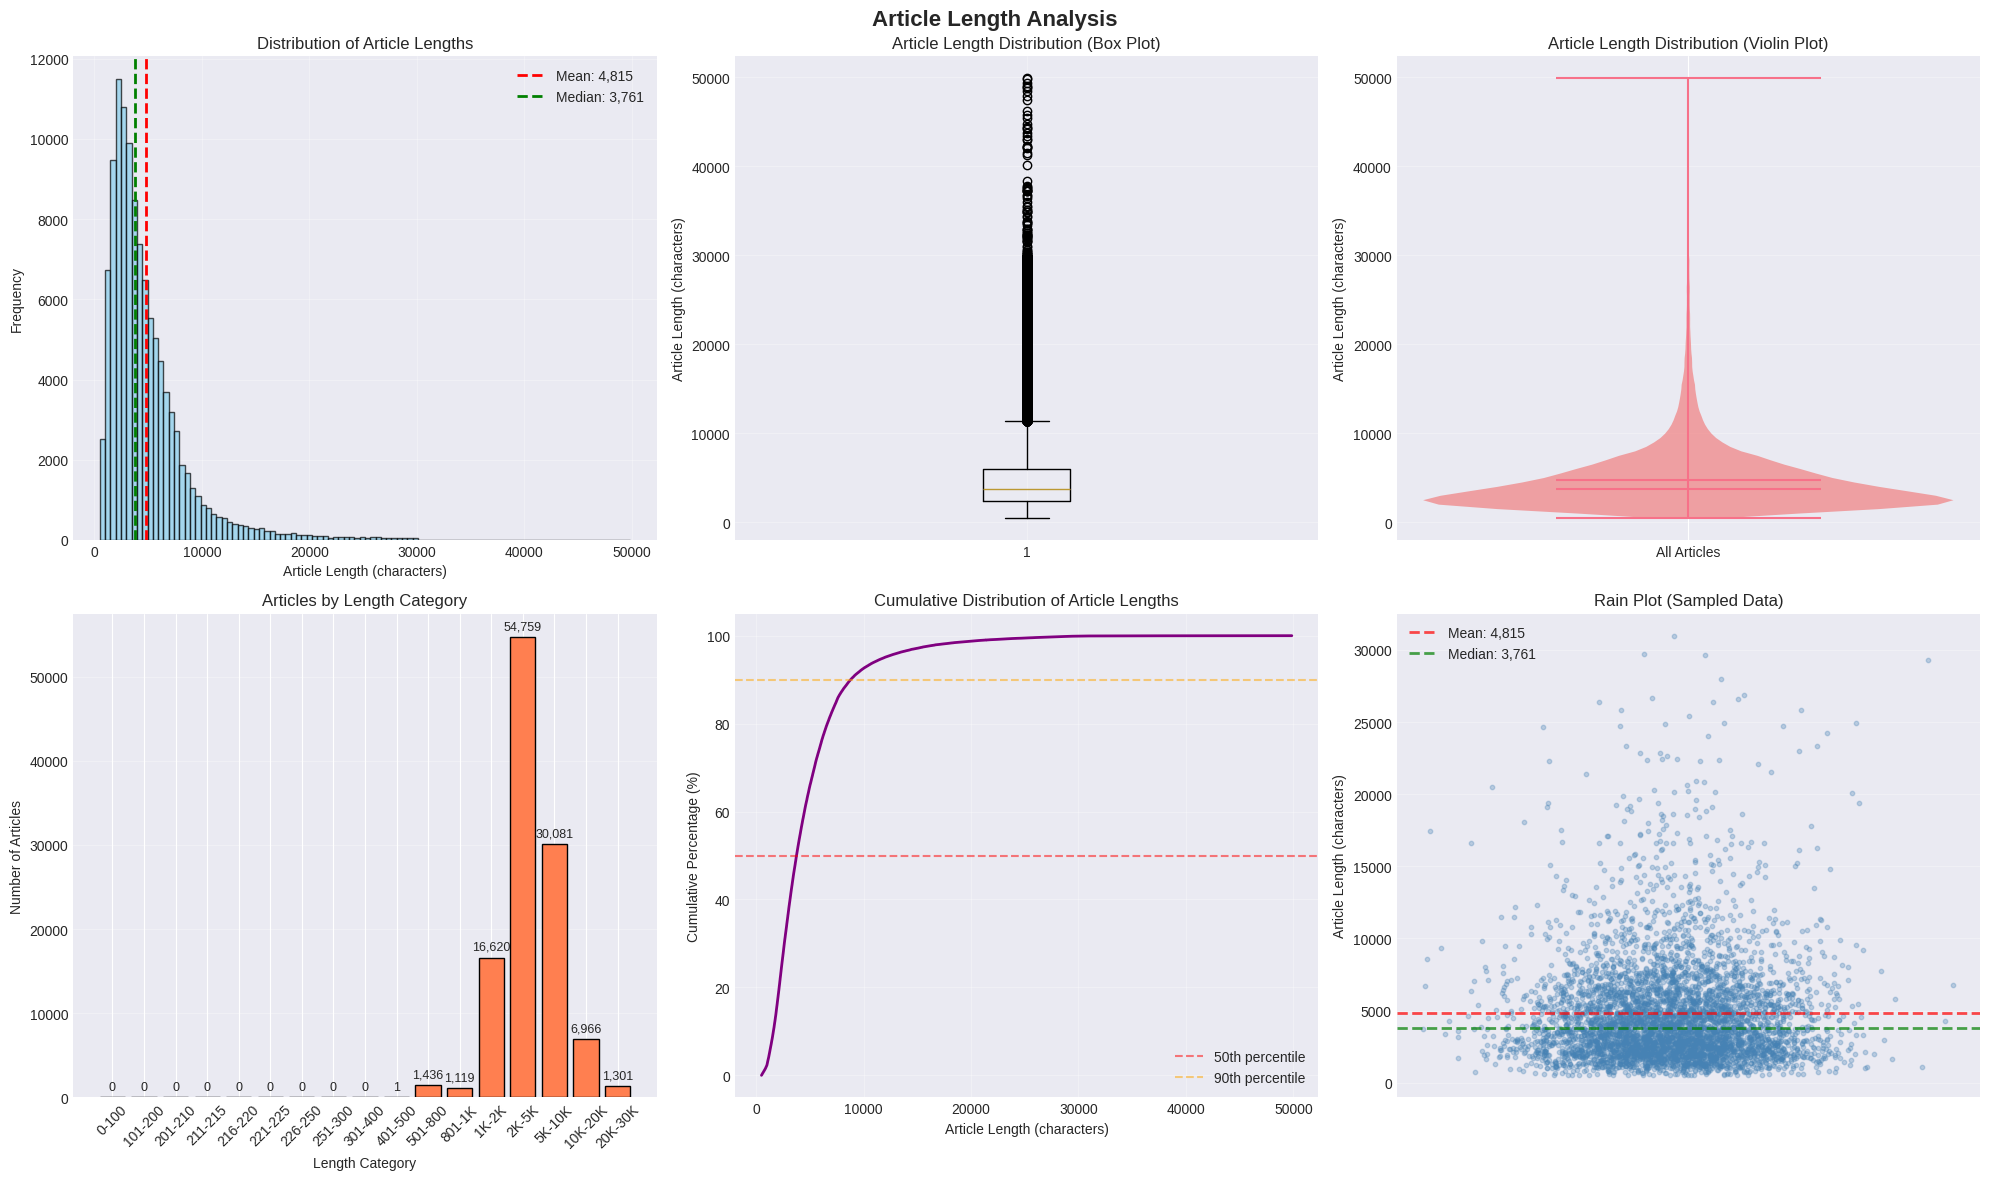

✅ Plot 1 complete!


In [18]:
# Step 2: Create comprehensive visualizations
import numpy as np

if 'df_all_data' in locals() and df_all_data is not None:
    
    print("=" * 100)
    print("📊 CREATING VISUALIZATIONS")
    print("=" * 100)
    
    # Set figure style
    plt.rcParams['figure.figsize'] = (15, 8)
    plt.rcParams['font.size'] = 10
    
    # ============================================================================
    # PLOT 1: Article Length Distribution (with Violin Plot)
    # ============================================================================
    print("\n🎨 Creating Plot 1: Article Length Distribution...")
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Article Length Analysis', fontsize=16, fontweight='bold')
    
    # 1.1 Histogram of article lengths
    axes[0, 0].hist(df_all_data['Article_Length'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Article Length (characters)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Article Lengths')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add statistics to the plot
    mean_len = df_all_data['Article_Length'].mean()
    median_len = df_all_data['Article_Length'].median()
    axes[0, 0].axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:,.0f}')
    axes[0, 0].axvline(median_len, color='green', linestyle='--', linewidth=2, label=f'Median: {median_len:,.0f}')
    axes[0, 0].legend()
    
    # 1.2 Box plot of article lengths
    axes[0, 1].boxplot(df_all_data['Article_Length'], vert=True)
    axes[0, 1].set_ylabel('Article Length (characters)')
    axes[0, 1].set_title('Article Length Distribution (Box Plot)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 1.3 Violin plot of article lengths
    parts = axes[0, 2].violinplot([df_all_data['Article_Length']], vert=True, 
                                   showmeans=True, showmedians=True)
    axes[0, 2].set_ylabel('Article Length (characters)')
    axes[0, 2].set_title('Article Length Distribution (Violin Plot)')
    axes[0, 2].set_xticks([1])
    axes[0, 2].set_xticklabels(['All Articles'])
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Color the violin plot
    for pc in parts['bodies']:
        pc.set_facecolor('lightcoral')
        pc.set_alpha(0.7)
    
    # 1.4 Categorized length distribution
    bins_cat = [0, 100,200,210,215,220,225,250,300,400,500,800, 1000, 2000, 5000, 10000, 20000, 30000]
    labels_cat = ['0-100','101-200', '201-210','211-215','216-220','221-225','226-250','251-300','301-400','401-500','501-800','801-1K', '1K-2K', '2K-5K', '5K-10K', '10K-20K', '20K-30K']
    df_all_data['Length_Category'] = pd.cut(
        df_all_data['Article_Length'], 
        bins=bins_cat, 
        labels=labels_cat
    )
    
    length_counts = df_all_data['Length_Category'].value_counts().sort_index()
    axes[1, 0].bar(range(len(length_counts)), length_counts.values, color='coral', edgecolor='black')
    axes[1, 0].set_xticks(range(len(length_counts)))
    axes[1, 0].set_xticklabels(length_counts.index, rotation=45)
    axes[1, 0].set_xlabel('Length Category')
    axes[1, 0].set_ylabel('Number of Articles')
    axes[1, 0].set_title('Articles by Length Category')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(length_counts.values):
        axes[1, 0].text(i, v + max(length_counts.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
    # 1.5 Cumulative distribution
    sorted_lengths = np.sort(df_all_data['Article_Length'])
    cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
    axes[1, 1].plot(sorted_lengths, cumulative, color='purple', linewidth=2)
    axes[1, 1].set_xlabel('Article Length (characters)')
    axes[1, 1].set_ylabel('Cumulative Percentage (%)')
    axes[1, 1].set_title('Cumulative Distribution of Article Lengths')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50th percentile')
    axes[1, 1].axhline(90, color='orange', linestyle='--', alpha=0.5, label='90th percentile')
    axes[1, 1].legend()
    
    # 1.6 Rain plot (strip plot with density)
    # Sample data for better visualization if too many points
    if len(df_all_data) > 5000:
        sample_data = df_all_data.sample(5000, random_state=42)
    else:
        sample_data = df_all_data
    
    # Create strip plot with jitter
    axes[1, 2].scatter(np.random.normal(0, 0.04, len(sample_data)), 
                       sample_data['Article_Length'], 
                       alpha=0.3, s=10, color='steelblue')
    axes[1, 2].set_ylabel('Article Length (characters)')
    axes[1, 2].set_title('Rain Plot (Sampled Data)')
    axes[1, 2].set_xticks([])
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    # Add mean and median lines
    axes[1, 2].axhline(mean_len, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_len:,.0f}', alpha=0.7)
    axes[1, 2].axhline(median_len, color='green', linestyle='--', linewidth=2, 
                       label=f'Median: {median_len:,.0f}', alpha=0.7)
    axes[1, 2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 1 complete!")
    
    # Drop temporary column
    df_all_data = df_all_data.drop('Length_Category', axis=1)
    
else:
    print("❌ No data available. Please run the data loading cell first.")


🎨 Creating Plot 2: Articles by Source...


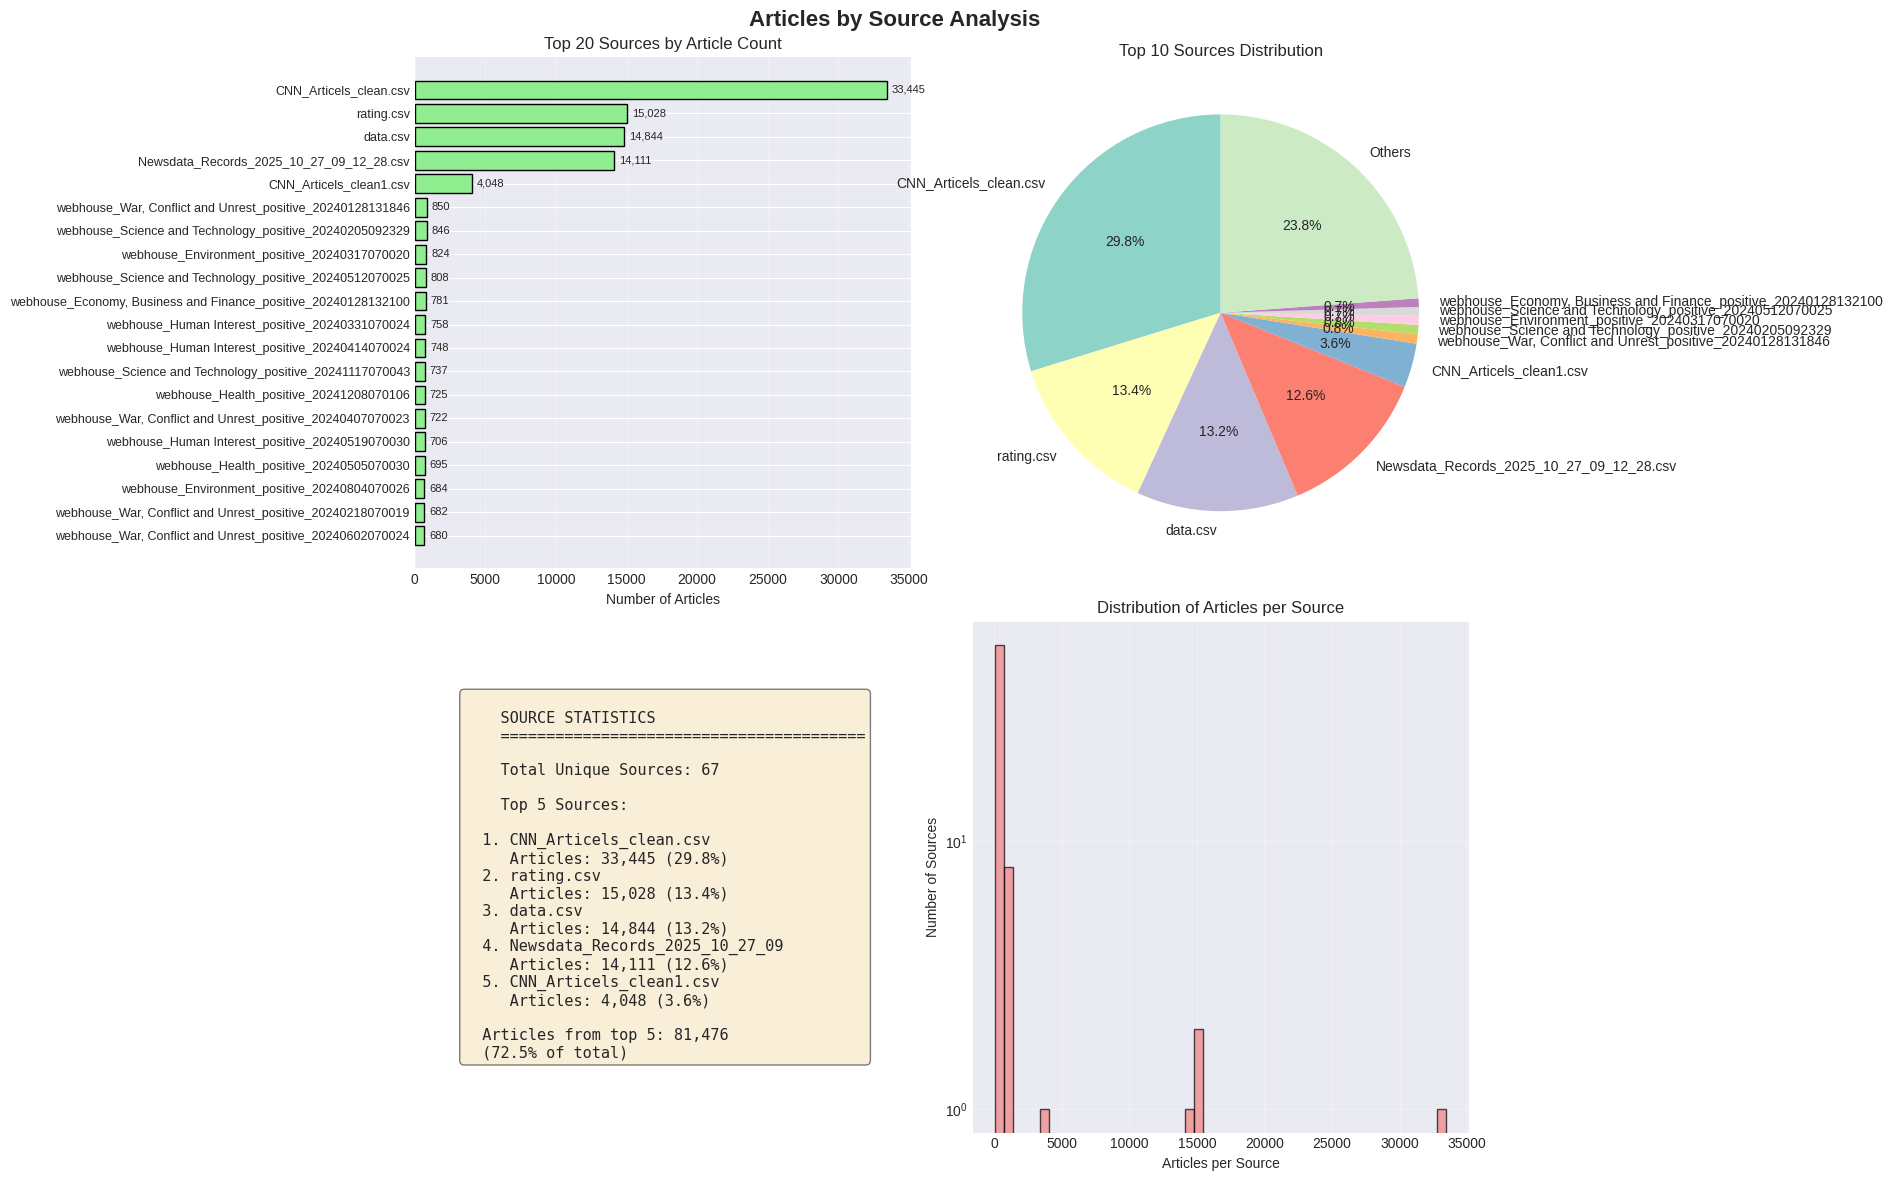

✅ Plot 2 complete!


In [19]:
# PLOT 2: Articles by Source
if 'df_all_data' in locals() and df_all_data is not None:
    
    print("\n🎨 Creating Plot 2: Articles by Source...")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Articles by Source Analysis', fontsize=16, fontweight='bold')
    
    # Count articles by source
    source_counts = df_all_data['Source'].value_counts()
    
    # 2.1 Bar chart of articles by source (top 20)
    top_sources = source_counts.head(20)
    axes[0, 0].barh(range(len(top_sources)), top_sources.values, color='lightgreen', edgecolor='black')
    axes[0, 0].set_yticks(range(len(top_sources)))
    axes[0, 0].set_yticklabels(top_sources.index, fontsize=9)
    axes[0, 0].set_xlabel('Number of Articles')
    axes[0, 0].set_title(f'Top 20 Sources by Article Count')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, v in enumerate(top_sources.values):
        axes[0, 0].text(v + max(top_sources.values)*0.01, i, f'{v:,}', va='center', fontsize=8)
    
    # 2.2 Pie chart of top 10 sources
    top_10_sources = source_counts.head(10)
    other_count = source_counts[10:].sum()
    
    # Combine with "Others"
    pie_data = list(top_10_sources.values) + [other_count]
    pie_labels = list(top_10_sources.index) + ['Others']
    
    colors = plt.cm.Set3(range(len(pie_data)))
    axes[0, 1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
    axes[0, 1].set_title('Top 10 Sources Distribution')
    
    # 2.3 Source distribution statistics
    axes[1, 0].axis('off')
    stats_text = f"""
    SOURCE STATISTICS
    {'='*40}
    
    Total Unique Sources: {len(source_counts)}
    
    Top 5 Sources:
    """
    for i, (source, count) in enumerate(source_counts.head(5).items(), 1):
        pct = (count / len(df_all_data) * 100)
        stats_text += f"\n  {i}. {source[:30]}\n     Articles: {count:,} ({pct:.1f}%)"
    
    stats_text += f"\n\n  Articles from top 5: {source_counts.head(5).sum():,}"
    stats_text += f"\n  ({source_counts.head(5).sum() / len(df_all_data) * 100:.1f}% of total)"
    
    axes[1, 0].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
                    verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2.4 Articles per source distribution
    articles_per_source = source_counts.values
    axes[1, 1].hist(articles_per_source, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Articles per Source')
    axes[1, 1].set_ylabel('Number of Sources')
    axes[1, 1].set_title('Distribution of Articles per Source')
    axes[1, 1].set_yscale('log')  # Log scale because of skewed distribution
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 2 complete!")
    
else:
    print("❌ No data available. Please run the data loading cell first.")


🎨 Creating Plot 3: Temporal Distribution...


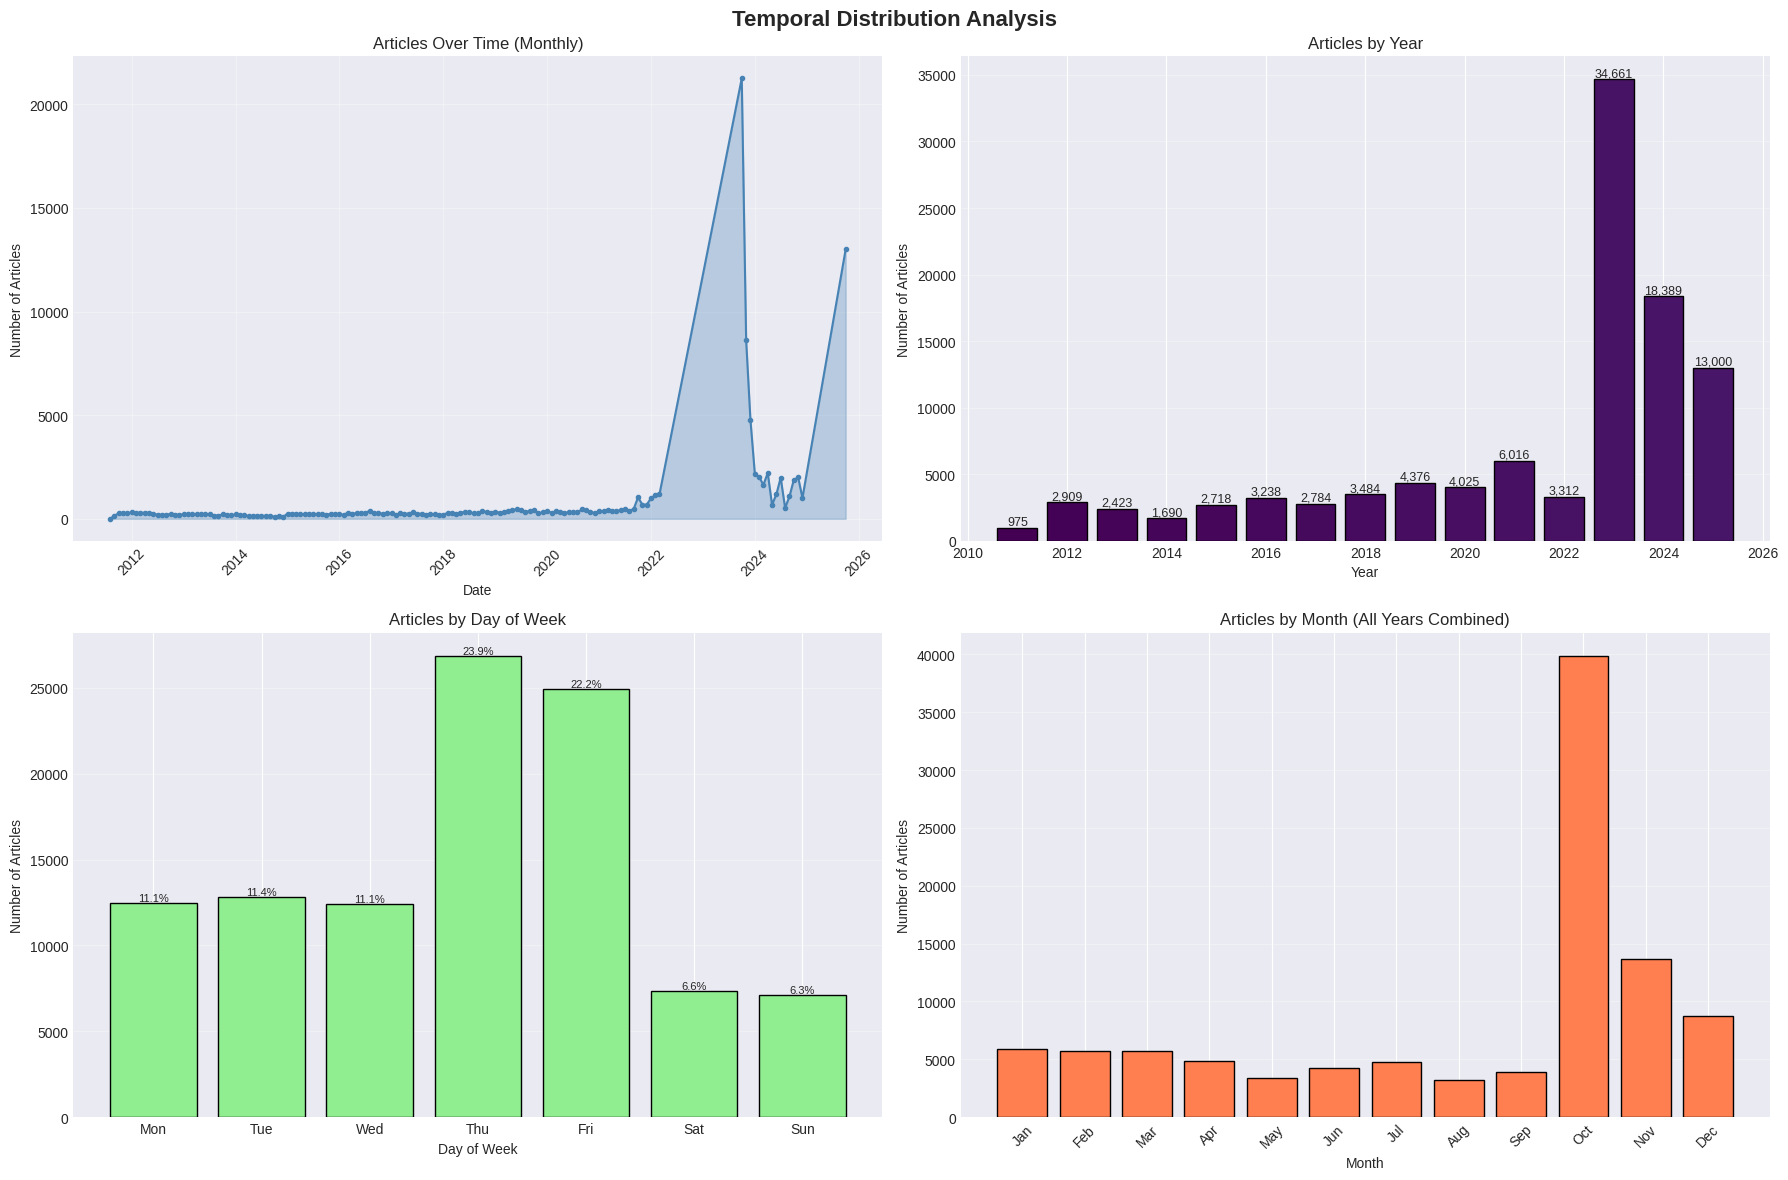

✅ Plot 3 complete!


In [20]:
# PLOT 3: Temporal Distribution
if 'df_all_data' in locals() and df_all_data is not None:
    
    print("\n🎨 Creating Plot 3: Temporal Distribution...")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Temporal Distribution Analysis', fontsize=16, fontweight='bold')
    
    # Extract temporal features
    df_all_data['Year'] = df_all_data['Date'].dt.year
    df_all_data['Month'] = df_all_data['Date'].dt.month
    df_all_data['YearMonth'] = df_all_data['Date'].dt.to_period('M')
    df_all_data['DayOfWeek'] = df_all_data['Date'].dt.dayofweek
    
    # 3.1 Timeline - Articles over time (monthly)
    monthly_counts = df_all_data.groupby('YearMonth').size()
    monthly_dates = [period.to_timestamp() for period in monthly_counts.index]
    
    axes[0, 0].plot(monthly_dates, monthly_counts.values, marker='o', markersize=3, linewidth=1.5, color='steelblue')
    axes[0, 0].fill_between(monthly_dates, monthly_counts.values, alpha=0.3, color='steelblue')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Number of Articles')
    axes[0, 0].set_title('Articles Over Time (Monthly)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 3.2 Yearly aggregation
    yearly_counts = df_all_data.groupby('Year').size()
    colors_yearly = plt.cm.viridis(range(len(yearly_counts)))
    
    bars = axes[0, 1].bar(yearly_counts.index, yearly_counts.values, color=colors_yearly, edgecolor='black')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Number of Articles')
    axes[0, 1].set_title('Articles by Year')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height):,}',
                        ha='center', va='bottom', fontsize=9)
    
    # 3.3 Day of week distribution
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    dow_counts = df_all_data.groupby('DayOfWeek').size()
    
    axes[1, 0].bar(range(7), [dow_counts.get(i, 0) for i in range(7)], 
                   color='lightgreen', edgecolor='black')
    axes[1, 0].set_xticks(range(7))
    axes[1, 0].set_xticklabels(day_names)
    axes[1, 0].set_xlabel('Day of Week')
    axes[1, 0].set_ylabel('Number of Articles')
    axes[1, 0].set_title('Articles by Day of Week')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    total_articles = len(df_all_data)
    for i in range(7):
        count = dow_counts.get(i, 0)
        pct = (count / total_articles * 100)
        axes[1, 0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # 3.4 Monthly distribution (across all years)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_dist = df_all_data.groupby('Month').size()
    
    axes[1, 1].bar(range(1, 13), [monthly_dist.get(i, 0) for i in range(1, 13)], 
                   color='coral', edgecolor='black')
    axes[1, 1].set_xticks(range(1, 13))
    axes[1, 1].set_xticklabels(month_names, rotation=45)
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Number of Articles')
    axes[1, 1].set_title('Articles by Month (All Years Combined)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Clean up temporary columns
    df_all_data.drop(['Year', 'Month', 'YearMonth', 'DayOfWeek'], axis=1, inplace=True)
    
    print("✅ Plot 3 complete!")
    
else:
    print("❌ No data available. Please run the data loading cell first.")


🎨 Creating Plot 4: Article Length by Source...


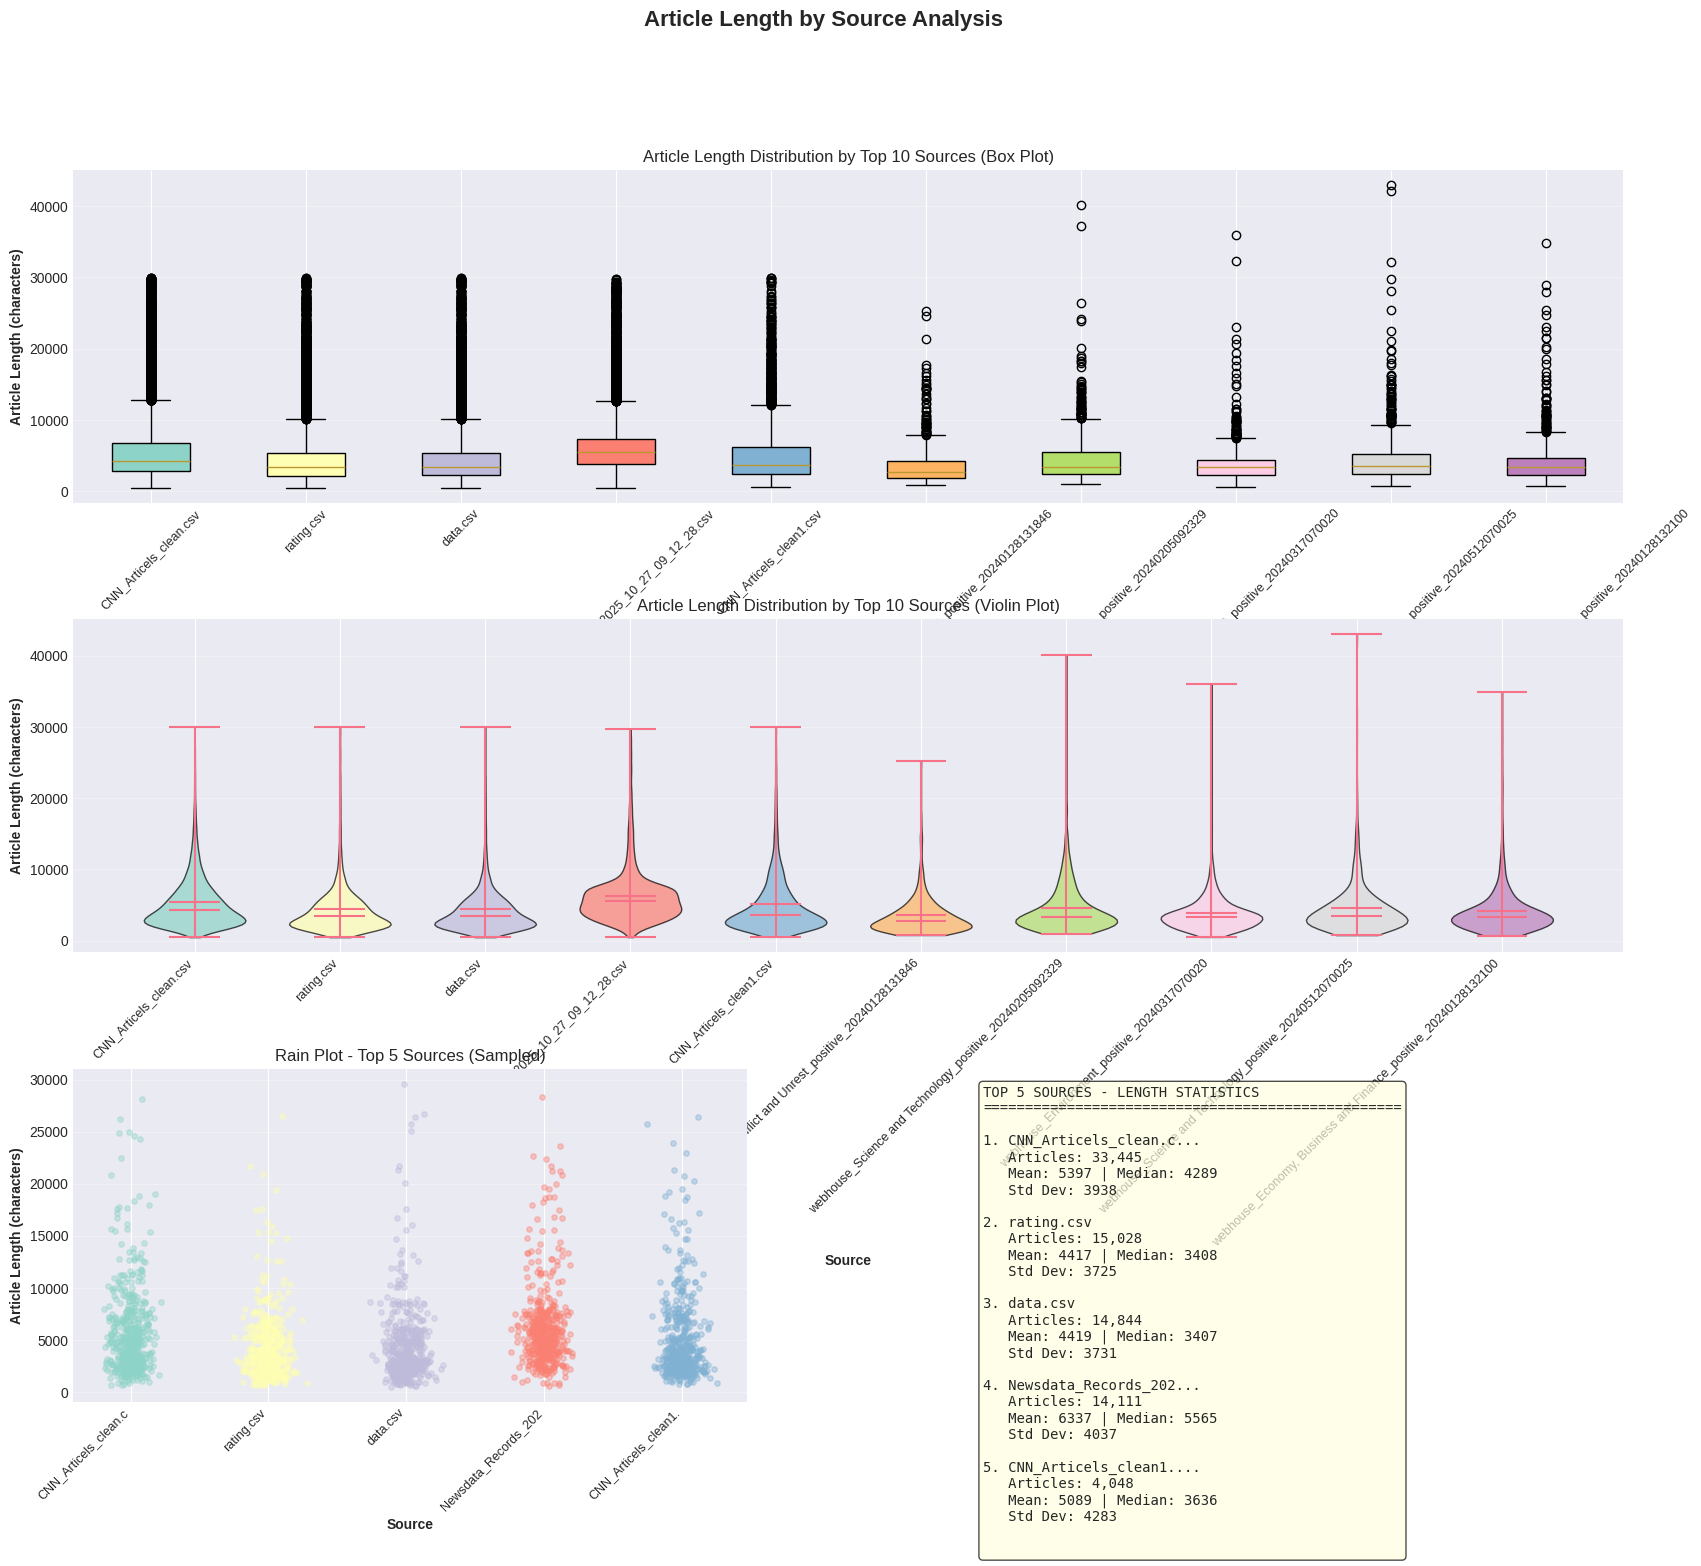

✅ Plot 4 complete!


In [13]:
# PLOT 4: Article Length by Source (with Box, Violin, and Rain Plots)
if 'df_all_data' in locals() and df_all_data is not None:
    
    print("\n🎨 Creating Plot 4: Article Length by Source...")
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    fig.suptitle('Article Length by Source Analysis', fontsize=16, fontweight='bold')
    
    # Get top 10 sources by article count (reduced for better visibility)
    top_sources = df_all_data['Source'].value_counts().head(10).index
    df_top_sources = df_all_data[df_all_data['Source'].isin(top_sources)]
    
    # 4.1 Box plot - Length distribution by source (top 10)
    ax1 = fig.add_subplot(gs[0, :])
    
    # Prepare data for box plot
    source_data = [df_top_sources[df_top_sources['Source'] == source]['Article_Length'].values 
                   for source in top_sources]
    
    bp = ax1.boxplot(source_data, labels=top_sources, patch_artist=True, vert=True)
    
    # Color the boxes
    colors = plt.cm.Set3(range(len(top_sources)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax1.set_xlabel('Source', fontweight='bold')
    ax1.set_ylabel('Article Length (characters)', fontweight='bold')
    ax1.set_title('Article Length Distribution by Top 10 Sources (Box Plot)')
    ax1.tick_params(axis='x', rotation=45, labelsize=9)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 4.2 Violin plot - Length distribution by source (top 10)
    ax2 = fig.add_subplot(gs[1, :])
    
    # Prepare data for violin plot
    positions = range(1, len(top_sources) + 1)
    parts = ax2.violinplot(source_data, positions=positions, 
                           showmeans=True, showmedians=True, widths=0.7)
    
    # Color the violin plots
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
    
    ax2.set_xticks(positions)
    ax2.set_xticklabels(top_sources, rotation=45, ha='right', fontsize=9)
    ax2.set_xlabel('Source', fontweight='bold')
    ax2.set_ylabel('Article Length (characters)', fontweight='bold')
    ax2.set_title('Article Length Distribution by Top 10 Sources (Violin Plot)')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 4.3 Rain plot - Length distribution by source (top 5 for clarity)
    ax3 = fig.add_subplot(gs[2, 0])
    
    top_5_sources = top_sources[:5]
    for i, source in enumerate(top_5_sources):
        source_lengths = df_top_sources[df_top_sources['Source'] == source]['Article_Length']
        # Sample if too many points
        if len(source_lengths) > 500:
            source_lengths = source_lengths.sample(500, random_state=42)
        
        # Add jitter to x-axis
        x_jitter = np.random.normal(i + 1, 0.08, len(source_lengths))
        ax3.scatter(x_jitter, source_lengths, alpha=0.4, s=15, color=colors[i])
    
    ax3.set_xticks(range(1, len(top_5_sources) + 1))
    ax3.set_xticklabels([s[:20] for s in top_5_sources], rotation=45, ha='right', fontsize=9)
    ax3.set_xlabel('Source', fontweight='bold')
    ax3.set_ylabel('Article Length (characters)', fontweight='bold')
    ax3.set_title('Rain Plot - Top 5 Sources (Sampled)')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4.4 Source length statistics table
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis('off')
    
    # Calculate statistics for top 10 sources
    stats_list = []
    for source in top_sources[:5]:
        source_data_stats = df_all_data[df_all_data['Source'] == source]['Article_Length']
        stats_list.append({
            'Source': source[:20] + '...' if len(source) > 20 else source,
            'Count': len(source_data_stats),
            'Mean': source_data_stats.mean(),
            'Median': source_data_stats.median(),
            'Std': source_data_stats.std()
        })
    
    # Create table text
    table_text = "TOP 5 SOURCES - LENGTH STATISTICS\n"
    table_text += "="*50 + "\n\n"
    
    for i, stat in enumerate(stats_list, 1):
        table_text += f"{i}. {stat['Source']}\n"
        table_text += f"   Articles: {stat['Count']:,}\n"
        table_text += f"   Mean: {stat['Mean']:.0f} | Median: {stat['Median']:.0f}\n"
        table_text += f"   Std Dev: {stat['Std']:.0f}\n\n"
    
    ax4.text(0.05, 0.95, table_text, fontsize=10, family='monospace',
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 4 complete!")
    
else:
    print("❌ No data available. Please run the data loading cell first.")


🎨 Creating Plot 5: Temporal Patterns and Coverage...


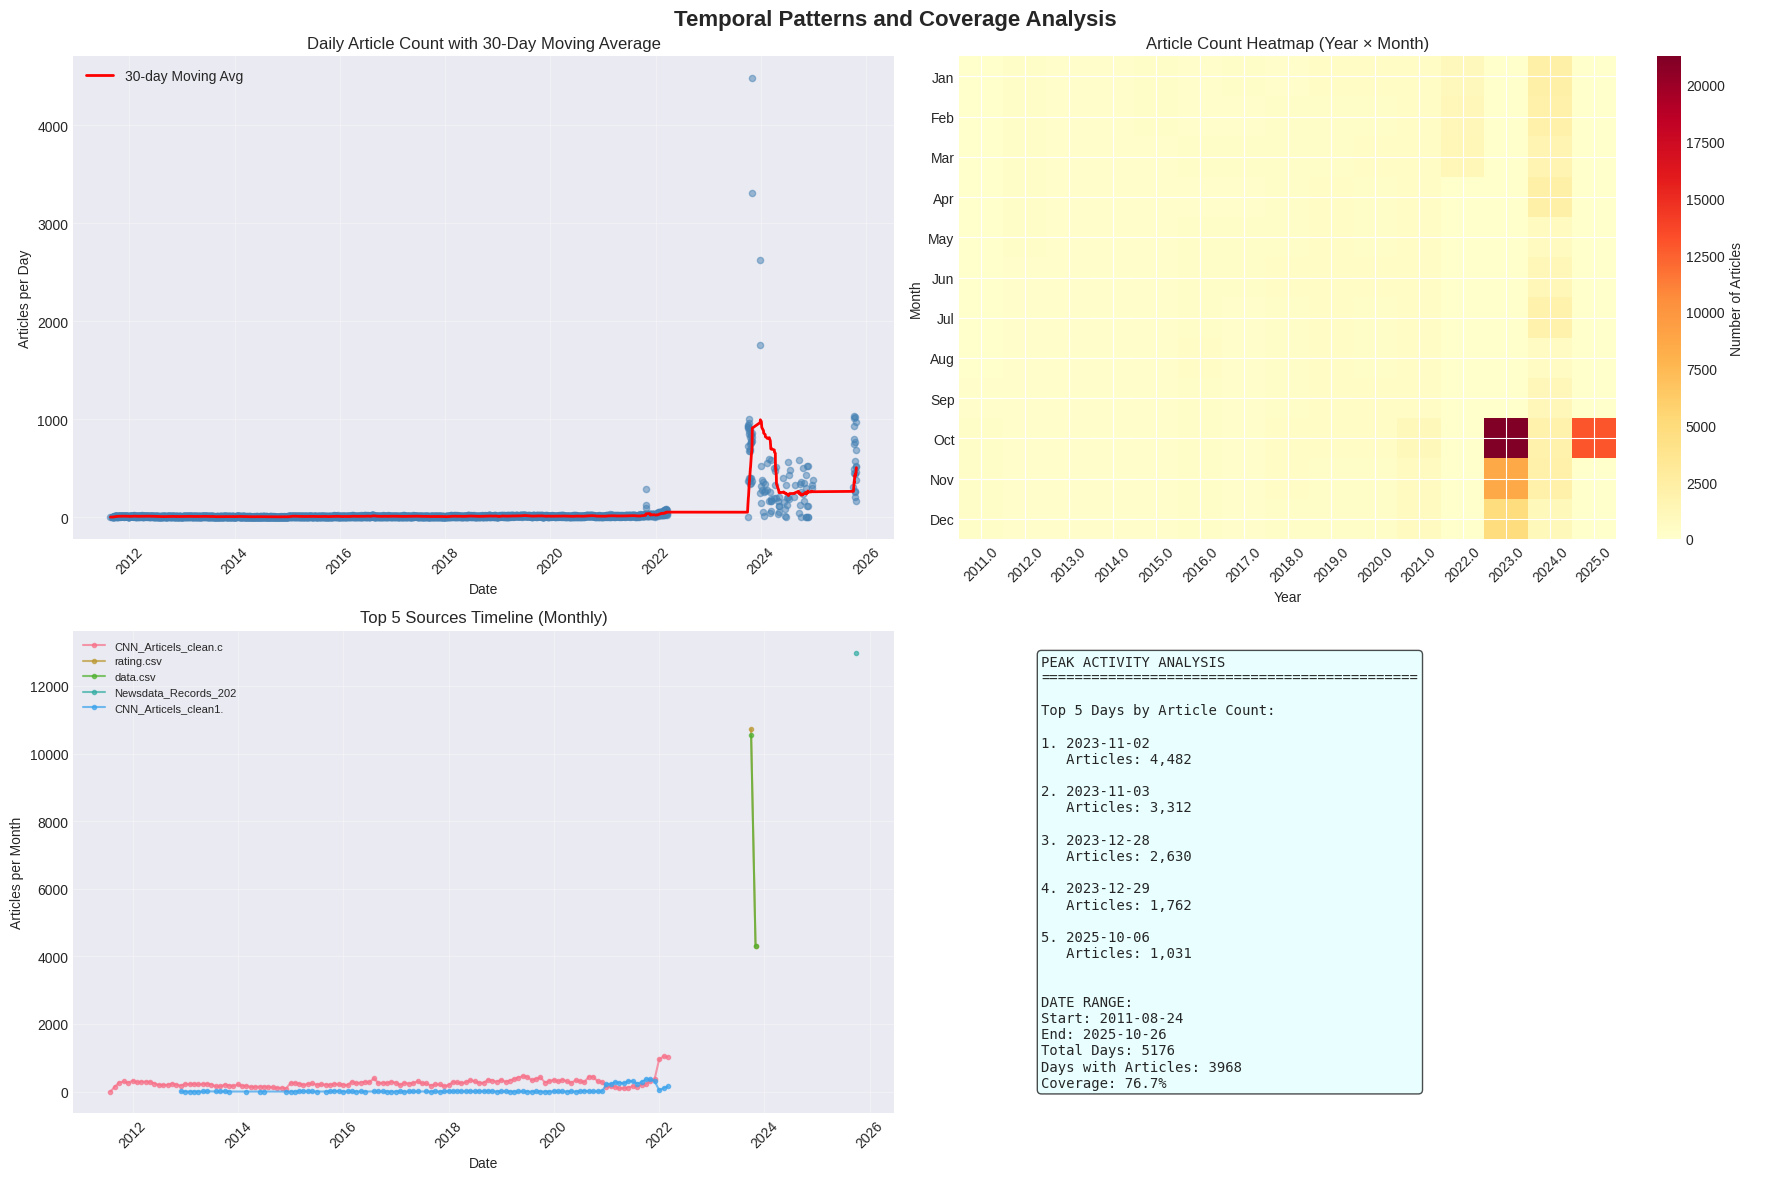

✅ Plot 5 complete!


In [14]:
# PLOT 5: Temporal Patterns and Coverage Analysis
if 'df_all_data' in locals() and df_all_data is not None:
    
    print("\n🎨 Creating Plot 5: Temporal Patterns and Coverage...")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Temporal Patterns and Coverage Analysis', fontsize=16, fontweight='bold')
    
    # 5.1 Articles per day (scatter plot with trend)
    daily_counts = df_all_data.groupby(df_all_data['Date'].dt.date).size()
    dates = [pd.Timestamp(d) for d in daily_counts.index]
    
    axes[0, 0].scatter(dates, daily_counts.values, alpha=0.5, s=20, color='steelblue')
    
    # Add moving average (30-day window)
    if len(daily_counts) >= 30:
        ma_30 = daily_counts.rolling(window=30, min_periods=1).mean()
        axes[0, 0].plot(dates, ma_30.values, color='red', linewidth=2, label='30-day Moving Avg')
        axes[0, 0].legend()
    
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Articles per Day')
    axes[0, 0].set_title('Daily Article Count with 30-Day Moving Average')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 5.2 Heatmap - Articles by Year and Month
    df_temp = df_all_data.copy()
    df_temp['Year'] = df_temp['Date'].dt.year
    df_temp['Month'] = df_temp['Date'].dt.month
    
    heatmap_data = df_temp.groupby(['Year', 'Month']).size().unstack(fill_value=0)
    
    im = axes[0, 1].imshow(heatmap_data.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    axes[0, 1].set_xticks(range(len(heatmap_data.index)))
    axes[0, 1].set_xticklabels(heatmap_data.index, rotation=45)
    axes[0, 1].set_yticks(range(12))
    axes[0, 1].set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Month')
    axes[0, 1].set_title('Article Count Heatmap (Year × Month)')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[0, 1], label='Number of Articles')
    
    # 5.3 Coverage timeline - Articles by top 10 sources over time
    top_5_sources = df_all_data['Source'].value_counts().head(5).index
    df_temp['YearMonth'] = df_temp['Date'].dt.to_period('M')
    
    for source in top_5_sources:
        source_data = df_temp[df_temp['Source'] == source].groupby('YearMonth').size()
        dates_source = [period.to_timestamp() for period in source_data.index]
        axes[1, 0].plot(dates_source, source_data.values, marker='o', markersize=3, 
                        linewidth=1.5, label=source[:20], alpha=0.7)
    
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Articles per Month')
    axes[1, 0].set_title('Top 5 Sources Timeline (Monthly)')
    axes[1, 0].legend(fontsize=8, loc='upper left')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 5.4 Peak activity analysis
    axes[1, 1].axis('off')
    
    # Find peaks
    top_10_days = daily_counts.nlargest(10)
    
    stats_text = "PEAK ACTIVITY ANALYSIS\n"
    stats_text += "="*45 + "\n\n"
    stats_text += "Top 5 Days by Article Count:\n\n"
    
    for i, (date, count) in enumerate(list(top_10_days.items())[:5], 1):
        stats_text += f"{i}. {date}\n"
        stats_text += f"   Articles: {count:,}\n\n"
    
    # Date range stats
    stats_text += f"\nDATE RANGE:\n"
    stats_text += f"Start: {df_all_data['Date'].min().date()}\n"
    stats_text += f"End: {df_all_data['Date'].max().date()}\n"
    stats_text += f"Total Days: {(df_all_data['Date'].max() - df_all_data['Date'].min()).days}\n"
    stats_text += f"Days with Articles: {len(daily_counts)}\n"
    stats_text += f"Coverage: {len(daily_counts) / (df_all_data['Date'].max() - df_all_data['Date'].min()).days * 100:.1f}%"
    
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                    verticalalignment='center', 
                    bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 5 complete!")
    
else:
    print("❌ No data available. Please run the data loading cell first.")


🎨 Creating Plot 6: Correlations and Summary Statistics...


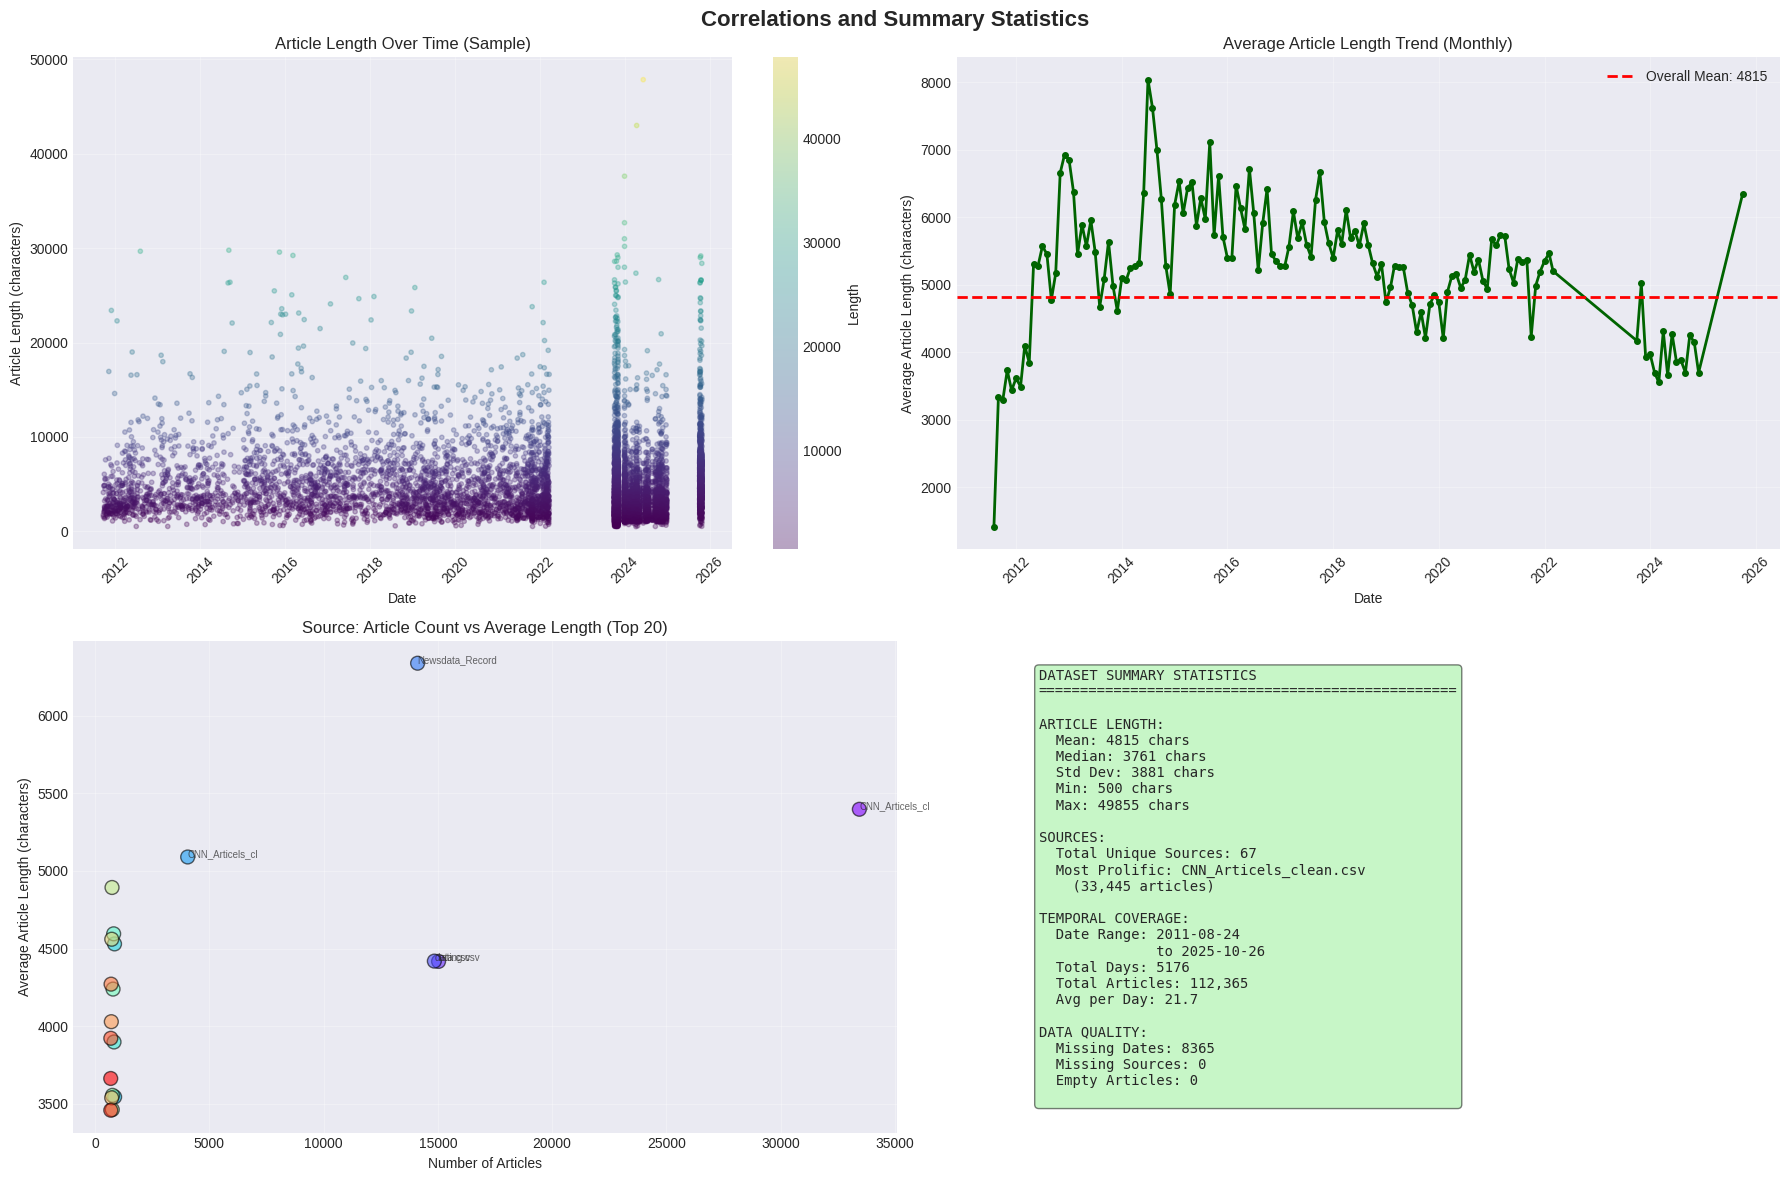

✅ Plot 6 complete!

🎉 ALL VISUALIZATIONS COMPLETE!


In [15]:
# PLOT 6: Correlations and Summary Statistics
if 'df_all_data' in locals() and df_all_data is not None:
    
    print("\n🎨 Creating Plot 6: Correlations and Summary Statistics...")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Correlations and Summary Statistics', fontsize=16, fontweight='bold')
    
    # 6.1 Length vs Time scatter plot
    # Sample data if too large (for performance) and remove NaN values
    if len(df_all_data) > 10000:
        df_sample = df_all_data.sample(10000, random_state=42)
    else:
        df_sample = df_all_data.copy()
    
    # Remove rows with NaN in Date or Article_Length
    df_sample = df_sample.dropna(subset=['Date', 'Article_Length'])
    
    # Convert dates to numeric for plotting
    dates_numeric = df_sample['Date'].values
    lengths = df_sample['Article_Length'].values
    
    scatter = axes[0, 0].scatter(dates_numeric, lengths, 
                                 alpha=0.3, s=10, c=lengths, 
                                 cmap='viridis', vmin=lengths.min(), vmax=lengths.max())
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Article Length (characters)')
    axes[0, 0].set_title('Article Length Over Time (Sample)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    plt.colorbar(scatter, ax=axes[0, 0], label='Length')
    
    # 6.2 Average length trend over time
    df_temp = df_all_data.copy()
    df_temp['YearMonth'] = df_temp['Date'].dt.to_period('M')
    monthly_avg_length = df_temp.groupby('YearMonth')['Article_Length'].mean()
    monthly_dates = [period.to_timestamp() for period in monthly_avg_length.index]
    
    axes[0, 1].plot(monthly_dates, monthly_avg_length.values, marker='o', 
                    markersize=4, linewidth=2, color='darkgreen')
    axes[0, 1].axhline(y=df_all_data['Article_Length'].mean(), color='red', 
                       linestyle='--', linewidth=2, label=f"Overall Mean: {df_all_data['Article_Length'].mean():.0f}")
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Average Article Length (characters)')
    axes[0, 1].set_title('Average Article Length Trend (Monthly)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 6.3 Source vs Average Length (top 20 sources)
    top_20_sources = df_all_data['Source'].value_counts().head(20).index
    source_avg_lengths = []
    source_counts = []
    
    for source in top_20_sources:
        source_data = df_all_data[df_all_data['Source'] == source]
        source_avg_lengths.append(source_data['Article_Length'].mean())
        source_counts.append(len(source_data))
    
    # Create color array properly
    colors_scatter = np.arange(len(top_20_sources))
    scatter2 = axes[1, 0].scatter(source_counts, source_avg_lengths, s=100, 
                                  alpha=0.6, c=colors_scatter, cmap='rainbow', edgecolors='black')
    
    # Add source labels for interesting points
    for i, source in enumerate(top_20_sources):
        if i < 5:  # Label top 5
            axes[1, 0].annotate(source[:15], (source_counts[i], source_avg_lengths[i]),
                               fontsize=7, alpha=0.7)
    
    axes[1, 0].set_xlabel('Number of Articles')
    axes[1, 0].set_ylabel('Average Article Length (characters)')
    axes[1, 0].set_title('Source: Article Count vs Average Length (Top 20)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 6.4 Overall Summary Statistics
    axes[1, 1].axis('off')
    
    summary_text = "DATASET SUMMARY STATISTICS\n"
    summary_text += "="*50 + "\n\n"
    summary_text += "ARTICLE LENGTH:\n"
    summary_text += f"  Mean: {df_all_data['Article_Length'].mean():.0f} chars\n"
    summary_text += f"  Median: {df_all_data['Article_Length'].median():.0f} chars\n"
    summary_text += f"  Std Dev: {df_all_data['Article_Length'].std():.0f} chars\n"
    summary_text += f"  Min: {df_all_data['Article_Length'].min():.0f} chars\n"
    summary_text += f"  Max: {df_all_data['Article_Length'].max():.0f} chars\n\n"
    
    summary_text += "SOURCES:\n"
    summary_text += f"  Total Unique Sources: {df_all_data['Source'].nunique()}\n"
    summary_text += f"  Most Prolific: {df_all_data['Source'].value_counts().index[0]}\n"
    summary_text += f"    ({df_all_data['Source'].value_counts().values[0]:,} articles)\n\n"
    
    summary_text += "TEMPORAL COVERAGE:\n"
    summary_text += f"  Date Range: {df_all_data['Date'].min().date()}\n"
    summary_text += f"              to {df_all_data['Date'].max().date()}\n"
    summary_text += f"  Total Days: {(df_all_data['Date'].max() - df_all_data['Date'].min()).days}\n"
    summary_text += f"  Total Articles: {len(df_all_data):,}\n"
    summary_text += f"  Avg per Day: {len(df_all_data) / (df_all_data['Date'].max() - df_all_data['Date'].min()).days:.1f}\n\n"
    
    # Data quality indicators
    summary_text += "DATA QUALITY:\n"
    summary_text += f"  Missing Dates: {df_all_data['Date'].isna().sum()}\n"
    summary_text += f"  Missing Sources: {df_all_data['Source'].isna().sum()}\n"
    summary_text += f"  Empty Articles: {(df_all_data['Article'].str.strip() == '').sum()}\n"
    
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                    verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Plot 6 complete!")
    print("\n" + "="*60)
    print("🎉 ALL VISUALIZATIONS COMPLETE!")
    print("="*60)
    
else:
    print("❌ No data available. Please run the data loading cell first.")